In [6]:
import numpy as np

def load_rowland_sessions(npz_path):
    """Load sessions from the exported .npz file."""
    data = np.load(npz_path, allow_pickle=True)
    session_ids = data['session_ids']
    
    sessions = {}
    for sid in session_ids:
        prefix = f"session_{sid}_"
        sessions[sid] = {
            'signature': str(data[f'{prefix}signature']),
            'mouse': str(data[f'{prefix}mouse']),
            'run_number': int(data[f'{prefix}run_number']),
            'name': str(data[f'{prefix}name']),
            'filter_ps_time': data[f'{prefix}filter_ps_time'],
            'behaviour_trials': data[f'{prefix}behaviour_trials'],
            'is_target': data[f'{prefix}is_target'],
            'trial_subsets': data[f'{prefix}trial_subsets'],
            'n_cells': int(data[f'{prefix}n_cells']),
            'n_trials': int(data[f'{prefix}n_trials']),
            'n_times': int(data[f'{prefix}n_times']),
            's1_bool': data[f'{prefix}s1_bool'],
            's2_bool': data[f'{prefix}s2_bool'],
            'outcome': data[f'{prefix}outcome'],
            'frequency': float(data[f'{prefix}frequency']),
        }
    return sessions

sessions=load_rowland_sessions('/home/patriciobarber/AdaptiveLatents/workspace/datasets/rowland23/all_sessions.npz')

s0 = sessions[0]

In [7]:
# --- CORRECTION OF TIMING ---
# Shift timing so that t=0 is one timepoint earlier
time_axis = s0['filter_ps_time']
dt = time_axis[1] - time_axis[0]
print(f"Original Time Range: {time_axis.min():.4f} to {time_axis.max():.4f}")

# The user wants the current index for 0 to now be +dt (or rather, the index -1 is the new 0).
# If correct t=0 is one timepoint BEFORE current t=0:
# Current: ... t[-1]=-dt, t[0]=0, t[1]=dt ...
# New:     ... t[-1]=0,   t[0]=dt, ... (This shifts time array to the right? No.)

# "stimulus onset 1 timepoint before before what is currently indicated"
# Current 0 is at index `zero_idx`.
# We want index `zero_idx - 1` to be the new 0.
# So we need to ADD `dt` to the time axis? 
# If t[zero_idx] = 0, and we want t[zero_idx-1] = 0.
# Currently t[zero_idx-1] = -dt. 
# To make it 0, we add dt. 
# Then t[zero_idx] becomes dt.

s0['filter_ps_time'] = s0['filter_ps_time'] + dt
time_axis = s0['filter_ps_time']
zero_idx = np.argmin(np.abs(time_axis))

print(f"Corrected Time Range: {time_axis.min():.4f} to {time_axis.max():.4f}")
print(f"New Stimulus Onset Index: {zero_idx}, Time: {time_axis[zero_idx]:.4f}s")

Original Time Range: -7.9667 to 6.0000
Corrected Time Range: -7.9333 to 6.0333
New Stimulus Onset Index: 238, Time: -0.0000s


In [8]:
import time
import builtins # Force built-in min
from dPCA import dPCA
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import matplotlib.patches as mpatches

# --- 1. Data Preparation (Standard 80/20 Split) ---
start_time = time.time()

# Extract data
neural_data = s0['behaviour_trials']  # (N, n_trials, T)
trial_subsets = s0['trial_subsets']   # Magnitude of stim per trial
n_trials = s0['n_trials']

# Standard random 80/20 split
all_indices = np.arange(n_trials)
train_indices, test_indices = train_test_split(
    all_indices,
    test_size=0.2,
    random_state=42,
    shuffle=True,
)
train_indices = np.sort(train_indices)
test_indices = np.sort(test_indices)

print(f"Data Split: {len(train_indices)} Training trials, {len(test_indices)} Test trials")
print(f"Training trial index range: [{train_indices.min()}, {train_indices.max()}]")

# Prepare dPCA data strictly from TRAINING trials only
unique_conditions = np.unique(trial_subsets)
trials_per_cond_train = {
    cond: np.intersect1d(np.where(trial_subsets == cond)[0], train_indices)
    for cond in unique_conditions
}

# Balanced trial count required by dPCA trial tensor shape (trials, N, S, T)
min_trials_train = builtins.min([len(t) for t in trials_per_cond_train.values()])

N, T = s0['n_cells'], s0['n_times']
S = len(unique_conditions)

# Construct trialR for dPCA (min_trials_train, N, S, T)
# Use random sampling from each training-condition pool to avoid biasing to earliest indices
rng = np.random.default_rng(42)
trialR = np.zeros((min_trials_train, N, S, T))
for s, cond in enumerate(unique_conditions):
    pool = trials_per_cond_train[cond]
    selected_trials = rng.choice(pool, size=min_trials_train, replace=False)
    for i, t_idx in enumerate(selected_trials):
        trialR[i, :, s, :] = neural_data[:, t_idx, :]

# Averaged R (N, S, T), centered from training-only trialR
R = np.mean(trialR, axis=0)
R_centered = R - np.mean(R.reshape((N, -1)), axis=1)[:, None, None]

print(f"dPCA Data Prepared from TRAIN ONLY. Shape: {trialR.shape}")
print(f"Balanced trials per condition used for dPCA fit: {min_trials_train}")
print(f"Preparation time: {time.time() - start_time:.4f}s")

Data Split: 129 Training trials, 33 Test trials
Training trial index range: [0, 161]
dPCA Data Prepared from TRAIN ONLY. Shape: (6, 471, 8, 420)
Balanced trials per condition used for dPCA fit: 6
Preparation time: 0.0269s


In [9]:
t0 = time.time()

dpca = dPCA.dPCA(labels='st', regularizer='auto', n_components=10)
dpca.protect = ['t']
Z = dpca.fit_transform(R_centered, trialR)

print(f"dPCA Fitting time: {time.time() - t0:.4f}s")

# --- Exponential Moving Average for smoothing dPCA trajectories ---
EMA_ALPHA = 0.2  # Smoothing factor: higher = less smoothing, lower = more smoothing

def apply_ema(z, alpha=EMA_ALPHA):
    """Apply exponential moving average along the time axis.
    z: (n_trials, T, d_z) array
    alpha: smoothing factor in (0, 1]. 1.0 = no smoothing.
    Returns smoothed array of same shape.
    """
    if z.ndim == 2:
        # (T, d_z)
        out = np.empty_like(z)
        out[0] = z[0]
        for t in range(1, z.shape[0]):
            out[t] = alpha * z[t] + (1 - alpha) * out[t - 1]
        return out
    elif z.ndim == 3:
        # (n_trials, T, d_z)
        out = np.empty_like(z)
        out[:, 0, :] = z[:, 0, :]
        for t in range(1, z.shape[1]):
            out[:, t, :] = alpha * z[:, t, :] + (1 - alpha) * out[:, t - 1, :]
        return out
    else:
        raise ValueError(f"Expected 2D or 3D array, got {z.ndim}D")

print(f"EMA smoothing function defined with alpha={EMA_ALPHA}")

You chose to determine the regularization parameter automatically. This can
                    take substantial time and grows linearly with the number of crossvalidation
                    folds. The latter can be set by changing self.n_trials (default = 3). Similarly,
                    use self.protect to set the list of axes that are not supposed to get to get shuffled
                    (e.g. upon splitting the data into test- and training, time-points should always
                    be drawn from the same trial, i.e. self.protect = ['t']). This can significantly
                    speed up the code.
Start optimizing regularization.
Starting trial  1 / 3
Starting trial  2 / 3
Starting trial  3 / 3
Optimized regularization, optimal lambda =  0.0008819763977946266
Regularization will be fixed; to compute the optimal                    parameter again on the next fit, please                    set opt_regularizer_flag to True.
dPCA Fitting time: 12.3906s
EMA smoothing function

In [10]:
# --- Variance accounting for top dPCA components + explainable variance ---
import pandas as pd

# Transform condition-averaged activity into dPCA space (same data used for fit)
Z_avg = dpca.transform(R_centered)  # dict of marginals, each ~ (n_comp, ...)

# Estimate total trial variance (signal + noise floor) and explainable variance (condition-averaged signal)
trial_flat = np.transpose(trialR, (0, 2, 3, 1)).reshape(-1, N)  # (trial*cond*time, neurons)
total_trial_variance = np.var(trial_flat, axis=0, ddof=0).sum()

R_full = np.mean(trialR, axis=0)  # (N, S, T), condition means before centering
R_full_centered = R_full - R_full.reshape(N, -1).mean(axis=1, keepdims=True)[:, None]
explainable_variance = np.var(R_full_centered.reshape(N, -1), axis=1, ddof=0).sum()

pct_explainable = 100.0 * explainable_variance / (total_trial_variance + 1e-12)

rows = []
for marginal in ["t", "s", "st"]:
    if marginal not in Z_avg:
        continue

    z_m = Z_avg[marginal]
    n_comp = z_m.shape[0]
    z_m_flat = z_m.reshape(n_comp, -1)

    # Variance per component across all condition/time points
    comp_var = np.var(z_m_flat, axis=1, ddof=0)

    top_var = float(comp_var[:5].sum())
    total_marginal_var = float(comp_var.sum())
    top_share_within_marginal = 100.0 * top_var / (total_marginal_var + 1e-12)
    top_share_of_explainable = 100.0 * top_var / (explainable_variance + 1e-12)
    top_share_of_total = 100.0 * top_var / (total_trial_variance + 1e-12)

    rows.append({
        "Marginal": marginal,
        "Top 5 PCs variance": top_var,
        "Top 5 PCs % of that marginal": top_share_within_marginal,
        "Top 5 PCs % of explainable variance": top_share_of_explainable,
        "Top 5 PCs % of total trial variance": top_share_of_total,
    })

df_var = pd.DataFrame(rows)
if len(df_var):
    print("Top 5 dPCA component variance summary (for marginals t, s, st):")
    display(df_var.style.format({
        "Top 5 PCs variance": "{:.6g}",
        "Top 5 PCs % of that marginal": "{:.2f}%",
        "Top 5 PCs % of explainable variance": "{:.2f}%",
        "Top 5 PCs % of total trial variance": "{:.2f}%",
    }))
else:
    print("No t/s/st marginals found in dPCA output.")

print("\nNoise-floor context:")
print(f"Total trial variance (signal + noise): {total_trial_variance:.6g}")
print(f"Explainable variance (condition-averaged signal): {explainable_variance:.6g}")
print(f"Percentage explainable variance: {pct_explainable:.2f}%")

# Optional combined metric: sum of top t,s,st components
if len(df_var):
    summed_top_var = float(df_var["Top 5 PCs variance"].sum())
    print(f"\nCombined top 5 (t,s,st) variance: {summed_top_var:.6g}")
    print(f"Combined top 5 (t,s,st) as % explainable: {100.0 * summed_top_var / (explainable_variance + 1e-12):.2f}%")
    print(f"Combined top 5 (t,s,st) as % total trial variance: {100.0 * summed_top_var / (total_trial_variance + 1e-12):.2f}%")

Top 5 dPCA component variance summary (for marginals t, s, st):


,Marginal,Top 5 PCs variance,Top 5 PCs % of that marginal,Top 5 PCs % of explainable variance,Top 5 PCs % of total trial variance
0,t,0.271238,99.79%,1.56%,0.28%
1,s,2.22463,97.30%,12.76%,2.33%
2,st,0.280428,94.15%,1.61%,0.29%



Noise-floor context:
Total trial variance (signal + noise): 95.3867
Explainable variance (condition-averaged signal): 17.4287
Percentage explainable variance: 18.27%

Combined top 5 (t,s,st) variance: 2.7763
Combined top 5 (t,s,st) as % explainable: 15.93%
Combined top 5 (t,s,st) as % total trial variance: 2.91%


## Understanding Variance Decomposition Metrics

The variance analysis above quantifies how much neural variability each dPCA component captures, providing multiple perspectives on component importance:

### Variance Metrics Explained

1. **Component Variance**: The raw variance captured by each principal component. Computed as `Var(Z_k)` where `Z_k` is the k-th component's trajectory across conditions and time.

2. **% of Marginal**: The component's variance as a percentage of its parent marginal's total variance. For example, if the top 't' component captures 73%, it accounts for 73% of all variance in the time marginal. This shows how dominant the top components are *within* each task parameter.

3. **% of Explainable Variance**: The component's variance as a percentage of the **explainable variance** (condition-averaged signal). Explainable variance represents the systematic, repeatable neural patterns across conditions—the "signal" as opposed to trial-to-trial noise. This metric shows how much of the interpretable neural signal each component captures.

4. **% of Total Trial Variance**: The component's variance as a percentage of total raw trial variance (signal + noise). Since neural recordings contain substantial trial-to-trial variability (noise floor), this percentage is typically much lower than the explainable percentage.

### Noise Floor Context

- **Total Trial Variance**: Sum of variances across all neurons, trials, conditions, and time—includes both systematic responses and noise.
- **Explainable Variance**: Variance of condition-averaged neural responses—represents only the repeatable, stimulus-locked signal.
- **Percentage Explainable**: The ratio `(Explainable / Total) × 100%`. Typical values of 15–25% indicate that most trial variance is due to noise, not systematic differences between conditions.

### Interpreting the Top-5 Analysis Below

The analysis below extends the single-component summary to the **top 5 components per marginal**. This reveals:
- How rapidly variance drops off within each marginal (eigenspectrum decay)
- The cumulative variance captured by multiple components
- Whether additional components contribute meaningfully or if the first component dominates

In [ ]:
# --- Variance accounting for TOP 5 dPCA components per marginal ---
import pandas as pd

# Use same variance estimates as above
# total_trial_variance and explainable_variance already computed in cell 6

rows_top5 = []
for marginal in ['t', 's', 'st']:
    if marginal not in Z_avg:
        continue
    
    # Variance of each component in this marginal
    comp_data = Z_avg[marginal]  # shape: (n_comp, S, T) or (n_comp, T) depending on marginal
    comp_var = np.var(comp_data, axis=tuple(range(1, comp_data.ndim)), ddof=0)
    
    total_marginal_var = float(comp_var.sum())
    
    # Analyze top 5 components
    n_show = min(5, len(comp_var))
    for rank in range(n_show):
        comp_variance = float(comp_var[rank])
        pct_of_marginal = 100.0 * comp_variance / (total_marginal_var + 1e-12)
        pct_of_explainable = 100.0 * comp_variance / (explainable_variance + 1e-12)
        pct_of_total = 100.0 * comp_variance / (total_trial_variance + 1e-12)
        
        rows_top5.append({
            "Marginal": marginal,
            "Rank": rank + 1,
            "PC variance": comp_variance,
            "% of marginal": pct_of_marginal,
            "% of explainable": pct_of_explainable,
            "% of total": pct_of_total,
        })

df_top5 = pd.DataFrame(rows_top5)

if len(df_top5):
    print("Top 5 dPCA components per marginal (t, s, st):\n")
    display(df_top5.style.format({
        "PC variance": "{:.6g}",
        "% of marginal": "{:.2f}%",
        "% of explainable": "{:.2f}%",
        "% of total": "{:.2f}%",
    }).set_properties(**{'text-align': 'center'}).set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'center')]}
    ]))
    
    # Cumulative statistics per marginal
    print("\n" + "="*70)
    print("Cumulative variance captured by top 5 components per marginal:")
    print("="*70)
    for marginal in ['t', 's', 'st']:
        marginal_rows = df_top5[df_top5['Marginal'] == marginal]
        if len(marginal_rows) == 0:
            continue
        cumulative_var = marginal_rows['PC variance'].sum()
        cumulative_pct_marginal = marginal_rows['% of marginal'].sum()
        cumulative_pct_explainable = marginal_rows['% of explainable'].sum()
        cumulative_pct_total = marginal_rows['% of total'].sum()
        
        print(f"\nMarginal '{marginal}':")
        print(f"  Total variance (top 5): {cumulative_var:.6g}")
        print(f"  Cumulative % of marginal: {cumulative_pct_marginal:.2f}%")
        print(f"  Cumulative % of explainable: {cumulative_pct_explainable:.2f}%")
        print(f"  Cumulative % of total: {cumulative_pct_total:.2f}%")
    
    # Grand total across all 15 components (5 per marginal × 3 marginals)
    grand_total_var = df_top5['PC variance'].sum()
    print("\n" + "="*70)
    print(f"Combined variance (all 15 components): {grand_total_var:.6g}")
    print(f"Combined as % of explainable: {100.0 * grand_total_var / (explainable_variance + 1e-12):.2f}%")
    print(f"Combined as % of total trial variance: {100.0 * grand_total_var / (total_trial_variance + 1e-12):.2f}%")
    print("="*70)
else:
    print("No marginals found for top-5 analysis.")

## LSTM Forecasting in dPCA Space with Post-dPCA Noise Augmentation

We model trial-wise latent dynamics in dPCA space using a controlled LSTM encoder–decoder. This cell uses the **post-dPCA augmentation** strategy: Gaussian noise is injected into the *normalized latent trajectories* (after dPCA projection and EMA smoothing), restricted to a peri-onset window and applied only to stimulated trials.

### Latent Representation

- Latent state: $\mathbf{z}_t \in \mathbb{R}^{d_z}$ (concatenation of $s$, $t$, and $st$ dPCA marginals)
- Stimulation vector: $\mathbf{v}_t \in \{0,1\}^{n_{\text{cells}}}$, where
  $$
  v_t[i] =
  \begin{cases}
  1, & \text{if neuron } i \text{ is photostimulated at time } t \\
  0, & \text{otherwise}
  \end{cases}
  $$

### Data Split

Standard random $80/20$ train-test split over trials (same seed as GRU experiments for comparability).

### LSTM Encoder–Decoder Architecture

Let $t_0$ be the stimulus-onset index and $H=20$ the forecast horizon.

**Encoder LSTM** — primes the hidden and cell states from all steps up to and including onset:
$$
(\mathbf{h}_t, \mathbf{c}_t) = \mathrm{LSTM}_{\text{enc}}\!\left([\mathbf{z}_t, \mathbf{v}_t],\; \mathbf{h}_{t-1},\; \mathbf{c}_{t-1}\right), \quad t \le t_0
$$

**Decoder LSTMCell** — autoregressive rollout from onset:
$$
(\mathbf{h}^{\text{dec}}_{k}, \mathbf{c}^{\text{dec}}_{k}) = \mathrm{LSTM}_{\text{dec}}\!\left([\tilde{\mathbf{z}}_{k-1}, \mathbf{v}_{t_0+k}],\; \mathbf{h}^{\text{dec}}_{k-1},\; \mathbf{c}^{\text{dec}}_{k-1}\right)
$$
$$
\hat{\mathbf{z}}_{t_0+k+1} = W_o \mathbf{h}^{\text{dec}}_{k} + b_o
$$
for $k=0,\dots,H-1$, where the initial $\tilde{\mathbf{z}}_0$ is the onset latent state and initial $(\mathbf{h}^{\text{dec}}_0, \mathbf{c}^{\text{dec}}_0)$ come from the encoder.

The key difference from GRU is that the LSTM maintains **separate hidden ($\mathbf{h}$) and cell ($\mathbf{c}$) states**, giving it a more flexible gating mechanism for long-range dependencies.

### Post-dPCA Noise Augmentation

For each **stimulated** training trial $i$ and each noisy copy $k \in \{1, \dots, K\}$:

1. Select the **peri-onset window** of $W = 10$ timesteps ($5$ pre-onset + $5$ post-onset):
   $$\mathcal{W} = \{t_0 - 5,\;\dots,\;t_0 + 4\}$$

2. Sample per-component Gaussian noise:
   $$\epsilon_{t,j} \sim \mathcal{N}\!\left(0,\;\left(\sigma_{\text{frac}} \cdot \hat{\sigma}_j\right)^2\right), \quad t \in \mathcal{W}$$
   where $\hat{\sigma}_j$ is the std of the $j$-th normalized latent component from the training set.

3. Inject noise **only inside the window**; timesteps outside $\mathcal{W}$ are unchanged.

4. **Stimulation vectors are never perturbed.**

5. Control (non-stimulated) trials are included **as clean samples only**.

Noise is re-drawn every `__getitem__` call, so the model never sees the same augmented sample twice.

### Variance-Weighted Loss & Metrics

Per-component variance weights from training data:
$$
w_j = \frac{\mathrm{Var}(z_j)}{\sum_{m=1}^{d_z} \mathrm{Var}(z_m)}, \quad \sum_j w_j = 1.
$$

**Training loss** — variance-weighted MSE:
$$
\mathcal{L} = \sum_{j=1}^{d_z} w_j \cdot \frac{1}{BH}\sum_{b=1}^{B}\sum_{h=1}^{H}\left(\hat{z}_{b,h,j} - z_{b,h,j}\right)^2
$$

**Evaluation metrics** at each horizon step $h$:
$$
\mathrm{MSE}^{\text{w}}_h = \sum_{j=1}^{d_z} w_j\,\mathrm{MSE}_{h,j},
\qquad
R^{2,\text{w}}_h = \sum_{j=1}^{d_z} w_j\,R^2_{h,j}.
$$

### Regularisation & Scheduling

- **AdamW** with decoupled weight decay $5 \times 10^{-4}$
- **ReduceLROnPlateau** scheduler: factor $0.5$, patience $10$ epochs, min lr $10^{-5}$
- **Early stopping**: patience $25$ epochs on test loss, restoring best weights
- **Dropout** $0.3$ applied uniformly to encoder inter-layer connections and decoder hidden states

### Hyperparameters

| Parameter | Value |
|---|---|
| Forecast horizon ($H$) | 20 |
| LSTM hidden size | 128 |
| Encoder / decoder layers | 2 |
| Dropout | 0.3 |
| Batch size | 32 |
| Max epochs | 200 |
| Optimizer | AdamW ($\text{lr}=10^{-3}$, weight decay $5 \times 10^{-4}$) |
| LR scheduler | ReduceLROnPlateau (factor=0.5, patience=10, min_lr=$10^{-5}$) |
| Early stopping patience | 25 epochs |
| Gradient clipping | 1.0 |
| Teacher forcing | linearly decayed from $0.7$ to $0.1$ |
| Noise copies per stimulated trial ($K$) | 20 |
| Noise scale ($\sigma_{\text{frac}}$) | 0.20 |
| Peri-onset window ($W$) | 10 (5 pre + 5 post) |
| EMA smoothing ($\alpha$) | 0.3 |

### Visualization

- Training & test loss curves (variance-weighted MSE)
- Weighted MSE and weighted $R^2$ vs forecast horizon ($t+1$ to $t+20$)
- Trial-specific trajectories for trial 34 in first 3 components (with 5 pre-onset steps)
- 3D trajectory comparison (actual vs predicted, from onset)
- 2D trajectory comparison (components 1 & 2, from onset)

Applied EMA smoothing (alpha=0.2) to dPCA trajectories
z_trial shape: (162, 420, 30)
stim vector shape: (162, 420, 471)
context_len=51, horizon=50, d_z=30, n_cells=471
Using peri-stimulus window: context [188, 239) and forecast [239, 289)
Priming: model consumes 50 pre-onset timesteps plus onset state, then predicts 50 post-onset timesteps.

Augmentation window: timesteps [233, 243) (10 steps, centered on onset at 238)
Noise std per component (first 5): [0.19999991 0.19999982 0.19999973 0.19999966 0.19999944]
Training trials: 82 stimulated, 47 control
Stimulated trials -> 1 clean + 20 noisy = 21 samples each
Control trials -> 1 clean sample each (no augmentation)
Effective train size per epoch: 1769
Epoch 001/200 | train_loss=0.550122 | test_loss=0.595047 | lr=1.0e-03 | tf=0.700 | no_improve=0
Epoch 020/200 | train_loss=0.044114 | test_loss=0.242657 | lr=1.0e-03 | tf=0.643 | no_improve=1
Epoch 040/200 | train_loss=0.039180 | test_loss=0.257454 | lr=5.0e-04 | tf=0.582 | no_improve=7
Epo

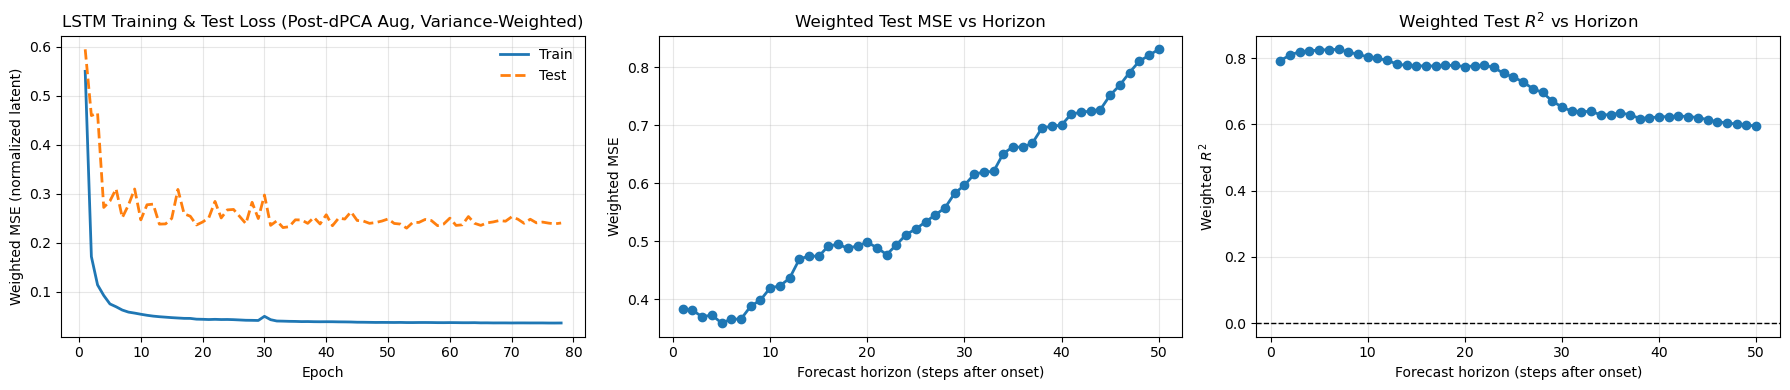

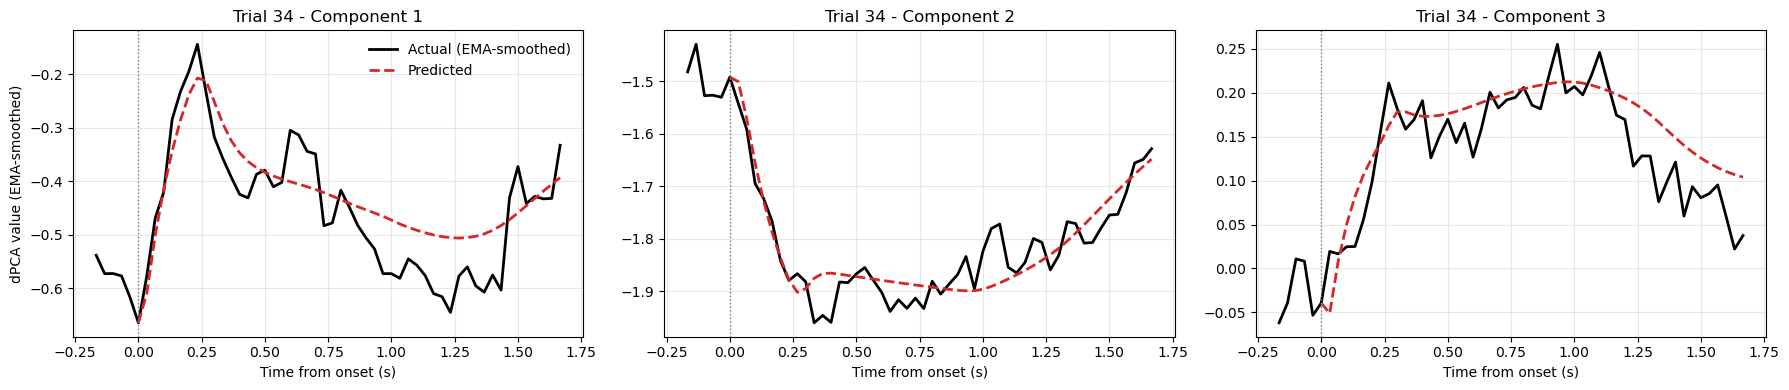

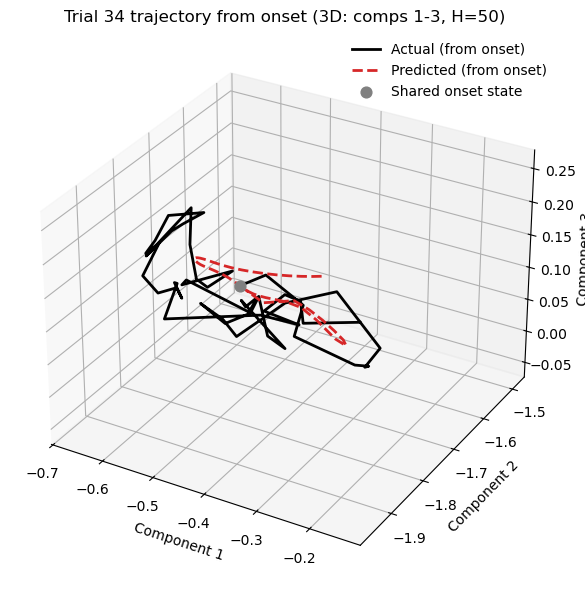

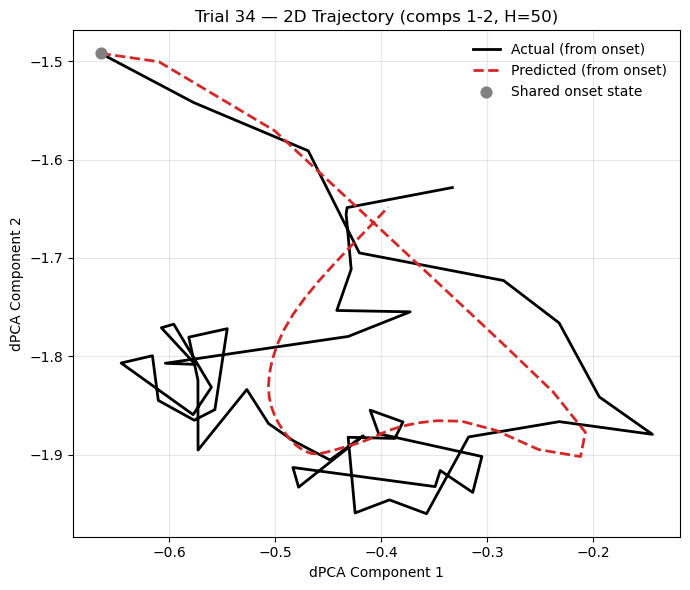

Timing:
Training time: 85.5046 s total (1.0962 s/epoch, 78 epochs)
Inference time (test batch of 33 trials, horizon=50): 0.003548 s
Inference time per trial: 0.000108 s

Weighted horizon-wise metrics (first 5 shown):
t+01: weighted MSE=0.38256, weighted R2=0.79285
t+02: weighted MSE=0.38089, weighted R2=0.80910
t+03: weighted MSE=0.36943, weighted R2=0.81977
t+04: weighted MSE=0.37253, weighted R2=0.82170
t+05: weighted MSE=0.35871, weighted R2=0.82466


In [7]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import copy

# =============================================================================
# 1) Build trial-wise trajectories in dPCA space and stimulus vectors
# =============================================================================

# Center all trials using the same mean used for dPCA fitting
stim_mean = np.mean(R.reshape((N, -1)), axis=1)[:, None, None]
neural_centered = neural_data - stim_mean

# Project each trial into dPCA marginals
z_all = dpca.transform(neural_centered)  # dict: each value is (n_comp, n_trials, T)

# Concatenate marginals to define full dPCA latent vector
z_trial = np.concatenate([z_all['s'], z_all['t'], z_all['st']], axis=0)  # (d_z, n_trials, T)
z_trial = np.transpose(z_trial, (1, 2, 0)).astype(np.float32)  # (n_trials, T, d_z)

# Apply EMA smoothing to dPCA trajectories
z_trial = apply_ema(z_trial, alpha=EMA_ALPHA)
print(f"Applied EMA smoothing (alpha={EMA_ALPHA}) to dPCA trajectories")

# Full stimulation vector over time (trial, time, neuron)
v = np.transpose(s0['is_target'], (1, 2, 0)).astype(np.float32)  # (n_trials, T, n_cells)

n_trials_total, T_total, d_z = z_trial.shape
n_cells = v.shape[-1]

# Forecast setup: train/eval only on a balanced peri-stimulus window
pre_event_steps = 50
post_event_steps = 50
context_start = zero_idx - pre_event_steps
context_end = zero_idx + 1  # include onset in context
forecast_start = zero_idx + 1
forecast_end = forecast_start + post_event_steps
context_len = context_end - context_start
horizon = forecast_end - forecast_start
assert context_start >= 0, "Not enough pre-onset steps for requested context window."
assert forecast_end <= T_total, "Not enough post-onset steps for requested forecast window."

# Normalization from training split only
z_train = z_trial[train_indices]
z_mean = z_train.mean(axis=(0, 1), keepdims=True)
z_std = z_train.std(axis=(0, 1), keepdims=True) + 1e-6
z_trial_n = (z_trial - z_mean) / z_std

# Variance contribution weights per latent component (from train set)
component_var = z_train.var(axis=(0, 1))
component_weights = component_var / (component_var.sum() + 1e-12)

print(f"z_trial shape: {z_trial.shape}")
print(f"stim vector shape: {v.shape}")
print(f"context_len={context_len}, horizon={horizon}, d_z={d_z}, n_cells={n_cells}")
print(f"Using peri-stimulus window: context [{context_start}, {context_end}) and forecast [{forecast_start}, {forecast_end})")
print("Priming: model consumes 50 pre-onset timesteps plus onset state, then predicts 50 post-onset timesteps.")

# =============================================================================
# 2) Augmentation parameters & dataset
# =============================================================================

n_augment = 20         # noisy copies per stimulated trial (increased for stronger regularisation)
noise_frac = 0.20      # noise std as fraction of per-component training std
aug_half_win = 5       # half-window: 5 pre + 5 post = 10 timesteps around onset

# Per-component std of normalized training latents
z_train_n = z_trial_n[train_indices]
z_comp_std = z_train_n.std(axis=(0, 1))  # (d_z,)
noise_std = (noise_frac * z_comp_std).astype(np.float32)

# Peri-onset window indices (clipped to valid range)
aug_start = max(zero_idx - aug_half_win, 0)
aug_end = min(zero_idx + aug_half_win, T_total)

# Identify stimulated trials
is_stimulated = v.reshape(v.shape[0], -1).any(axis=1)  # (n_trials_total,)
train_stim_mask = is_stimulated[train_indices]
n_stim_train = int(train_stim_mask.sum())
n_ctrl_train = len(train_indices) - n_stim_train

print(f"\nAugmentation window: timesteps [{aug_start}, {aug_end}) "
      f"({aug_end - aug_start} steps, centered on onset at {zero_idx})")
print(f"Noise std per component (first 5): {noise_std[:5]}")
print(f"Training trials: {n_stim_train} stimulated, {n_ctrl_train} control")
print(f"Stimulated trials -> 1 clean + {n_augment} noisy = {1 + n_augment} samples each")
print(f"Control trials -> 1 clean sample each (no augmentation)")
print(f"Effective train size per epoch: {n_stim_train * (1 + n_augment) + n_ctrl_train}")


class OnsetForecastDataset(Dataset):
    """Clean dataset for test evaluation."""
    def __init__(self, trial_indices):
        self.trial_indices = np.array(trial_indices)

    def __len__(self):
        return len(self.trial_indices)

    def __getitem__(self, idx):
        tr = self.trial_indices[idx]
        context_z = z_trial_n[tr, context_start:context_end, :]
        context_v = v[tr, context_start:context_end, :]
        future_v = v[tr, forecast_start:forecast_end, :]
        target_z = z_trial_n[tr, forecast_start:forecast_end, :]
        return (
            torch.from_numpy(context_z),
            torch.from_numpy(context_v),
            torch.from_numpy(future_v),
            torch.from_numpy(target_z),
        )


class AugmentedOnsetForecastDataset(Dataset):
    """Training dataset: augments *only stimulated trials* with peri-onset noise.

    For each stimulated trial: 1 clean + n_augment noisy copies.
    For each control trial:    1 clean copy only.
    Noise is re-sampled every __getitem__ call.
    """

    def __init__(self, trial_indices, stim_mask, n_augment, noise_std, aug_start, aug_end):
        self.noise_std = noise_std
        self.aug_start = aug_start
        self.aug_end = aug_end

        self.items = []
        for i, tr in enumerate(trial_indices):
            self.items.append((tr, 0))  # clean
            if stim_mask[i]:
                for k in range(1, n_augment + 1):
                    self.items.append((tr, k))

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        tr, copy_idx = self.items[idx]

        context_z = z_trial_n[tr, context_start:context_end, :].copy()
        context_v = v[tr, context_start:context_end, :]
        future_v  = v[tr, forecast_start:forecast_end, :]
        target_z  = z_trial_n[tr, forecast_start:forecast_end, :].copy()

        if copy_idx > 0:
            # Context part of the window
            ctx_noise_start = max(self.aug_start, context_start) - context_start
            ctx_noise_end = min(self.aug_end, context_end) - context_start
            if ctx_noise_end > ctx_noise_start:
                n_ctx = ctx_noise_end - ctx_noise_start
                context_z[ctx_noise_start:ctx_noise_end, :] += (
                    np.random.randn(n_ctx, len(self.noise_std)).astype(np.float32) * self.noise_std
                )

            # Target (forecast) part of the window
            tgt_global_start = forecast_start
            tgt_global_end = forecast_end
            tgt_noise_start = max(self.aug_start, tgt_global_start) - tgt_global_start
            tgt_noise_end = min(self.aug_end, tgt_global_end) - tgt_global_start
            if tgt_noise_end > tgt_noise_start:
                n_tgt = tgt_noise_end - tgt_noise_start
                target_z[tgt_noise_start:tgt_noise_end, :] += (
                    np.random.randn(n_tgt, len(self.noise_std)).astype(np.float32) * self.noise_std
                )

        return (
            torch.from_numpy(context_z),
            torch.from_numpy(context_v),
            torch.from_numpy(future_v),
            torch.from_numpy(target_z),
        )


aug_train_ds = AugmentedOnsetForecastDataset(
    train_indices, stim_mask=train_stim_mask, n_augment=n_augment,
    noise_std=noise_std, aug_start=aug_start, aug_end=aug_end,
)
aug_train_loader = DataLoader(aug_train_ds, batch_size=32, shuffle=True)

# Test set stays clean
test_ds = OnsetForecastDataset(test_indices)
test_loader = DataLoader(test_ds, batch_size=len(test_ds), shuffle=False)

# =============================================================================
# 3) LSTM model with stimulus control input
# =============================================================================

class LSTMStimForecast(nn.Module):
    """LSTM encoder-decoder for controlled latent-space forecasting.

    Encoder: multi-layer LSTM consuming [z_t, v_t] context up to onset.
    Decoder: autoregressive LSTMCell rollout, receiving stimulus at each step.
    """

    def __init__(self, latent_dim, stim_dim, hidden_dim=128, num_layers=2, dropout=0.3):
        super().__init__()
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim

        # Encoder LSTM (dropout applies between layers when num_layers > 1)
        self.encoder = nn.LSTM(
            input_size=latent_dim + stim_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        # Decoder LSTMCells (one per layer)
        self.decoder_cells = nn.ModuleList()
        self.decoder_cells.append(nn.LSTMCell(latent_dim + stim_dim, hidden_dim))
        for _ in range(1, num_layers):
            self.decoder_cells.append(nn.LSTMCell(hidden_dim, hidden_dim))

        self.readout = nn.Linear(hidden_dim, latent_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, context_z, context_v, future_v, target_z=None, teacher_forcing=0.0):
        # Encode context (up to and including onset)
        enc_in = torch.cat([context_z, context_v], dim=-1)
        _, (h_n, c_n) = self.encoder(enc_in)  # h_n, c_n: (num_layers, batch, hidden)

        # Start from onset latent state (last context step)
        prev_z = context_z[:, -1, :]
        preds = []
        H = future_v.shape[1]

        for k in range(H):
            dec_in = torch.cat([prev_z, future_v[:, k, :]], dim=-1)
            h_in = dec_in
            h_new = []
            c_new = []
            for layer_idx, cell in enumerate(self.decoder_cells):
                h_l, c_l = cell(h_in, (h_n[layer_idx], c_n[layer_idx]))
                h_l = self.dropout(h_l)
                h_new.append(h_l)
                c_new.append(c_l)
                h_in = h_l
            h_n = torch.stack(h_new, dim=0)
            c_n = torch.stack(c_new, dim=0)
            pred_z = self.readout(h_n[-1])
            preds.append(pred_z.unsqueeze(1))

            if self.training and target_z is not None and teacher_forcing > 0.0:
                use_teacher = (torch.rand(pred_z.shape[0], device=pred_z.device) < teacher_forcing).float().unsqueeze(-1)
                prev_z = use_teacher * target_z[:, k, :] + (1.0 - use_teacher) * pred_z
            else:
                prev_z = pred_z

        return torch.cat(preds, dim=1)

# =============================================================================
# 4) Train LSTM — AdamW + ReduceLROnPlateau + early stopping
# =============================================================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LSTMStimForecast(
    latent_dim=d_z, stim_dim=n_cells, hidden_dim=128, num_layers=2, dropout=0.3
).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-5
)

# Variance-weighted MSE
component_weights_t = torch.from_numpy(component_weights).float().to(device)

def weighted_mse_loss(pred, target, weights):
    """Compute variance-weighted MSE: average over batch & horizon, then weight per component."""
    per_comp_mse = ((pred - target) ** 2).mean(dim=(0, 1))  # (d_z,)
    return (weights * per_comp_mse).sum()

n_epochs = 200
early_stop_patience = 25
loss_history = []
test_loss_history = []

best_test_loss = float('inf')
best_model_state = None
epochs_no_improve = 0

train_t0 = time.perf_counter()
for epoch in range(1, n_epochs + 1):
    model.train()
    running_loss = 0.0

    tf_ratio = 0.7 + (0.1 - 0.7) * ((epoch - 1) / max(n_epochs - 1, 1))

    for context_z_b, context_v_b, future_v_b, target_z_b in aug_train_loader:
        context_z_b = context_z_b.to(device)
        context_v_b = context_v_b.to(device)
        future_v_b = future_v_b.to(device)
        target_z_b = target_z_b.to(device)

        optimizer.zero_grad()
        pred_z_b = model(context_z_b, context_v_b, future_v_b, target_z=target_z_b, teacher_forcing=tf_ratio)
        loss = weighted_mse_loss(pred_z_b, target_z_b, component_weights_t)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        running_loss += loss.item() * context_z_b.shape[0]

    epoch_loss = running_loss / len(aug_train_ds)
    loss_history.append(epoch_loss)

    # Compute test loss (open-loop, no teacher forcing)
    model.eval()
    with torch.no_grad():
        test_running = 0.0
        for context_z_b, context_v_b, future_v_b, target_z_b in test_loader:
            context_z_b = context_z_b.to(device)
            context_v_b = context_v_b.to(device)
            future_v_b = future_v_b.to(device)
            target_z_b = target_z_b.to(device)
            pred_z_b = model(context_z_b, context_v_b, future_v_b, target_z=None, teacher_forcing=0.0)
            test_running += weighted_mse_loss(pred_z_b, target_z_b, component_weights_t).item() * context_z_b.shape[0]
        current_test_loss = test_running / len(test_ds)
        test_loss_history.append(current_test_loss)

    # LR scheduler step
    scheduler.step(current_test_loss)

    # Early stopping check
    if current_test_loss < best_test_loss:
        best_test_loss = current_test_loss
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epoch % 20 == 0 or epoch == 1:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch:03d}/{n_epochs} | train_loss={epoch_loss:.6f} | test_loss={current_test_loss:.6f} | "
              f"lr={current_lr:.1e} | tf={tf_ratio:.3f} | no_improve={epochs_no_improve}")

    if epochs_no_improve >= early_stop_patience:
        print(f"\nEarly stopping at epoch {epoch} (no improvement for {early_stop_patience} epochs).")
        print(f"Best test loss: {best_test_loss:.6f}")
        break

training_time_sec = time.perf_counter() - train_t0
actual_epochs = epoch  # number of epochs actually trained

# Restore best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"Restored best model weights (test loss = {best_test_loss:.6f})")

# =============================================================================
# 5) Evaluate weighted horizon-wise metrics on test set
# =============================================================================

model.eval()
with torch.no_grad():
    (context_z_t, context_v_t, future_v_t, target_z_t) = next(iter(test_loader))
    context_z_t = context_z_t.to(device)
    context_v_t = context_v_t.to(device)
    future_v_t = future_v_t.to(device)

    if device.type == 'cuda':
        torch.cuda.synchronize()
    infer_t0 = time.perf_counter()
    pred_z_t = model(context_z_t, context_v_t, future_v_t, target_z=None, teacher_forcing=0.0)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    inference_time_sec = time.perf_counter() - infer_t0

pred_z_t = pred_z_t.cpu().numpy()
target_z_t = target_z_t.numpy()

pred_z = pred_z_t * z_std + z_mean
target_z = target_z_t * z_std + z_mean

horizons = np.arange(1, horizon + 1)
weighted_mse_by_h = []
weighted_r2_by_h = []

for h in range(horizon):
    y_true_h = target_z[:, h, :]
    y_pred_h = pred_z[:, h, :]

    mse_per_comp = np.mean((y_pred_h - y_true_h) ** 2, axis=0)
    weighted_mse = float(np.sum(component_weights * mse_per_comp))

    r2_per_comp = np.zeros(d_z, dtype=np.float64)
    for comp in range(d_z):
        if np.var(y_true_h[:, comp]) < 1e-12:
            r2_per_comp[comp] = 0.0
        else:
            r2_per_comp[comp] = r2_score(y_true_h[:, comp], y_pred_h[:, comp])
    weighted_r2 = float(np.sum(component_weights * r2_per_comp))

    weighted_mse_by_h.append(weighted_mse)
    weighted_r2_by_h.append(weighted_r2)

# =============================================================================
# 6) Plot training curve + weighted horizon-wise MSE and R²
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(np.arange(1, actual_epochs + 1), loss_history, lw=2, label='Train')
axes[0].plot(np.arange(1, actual_epochs + 1), test_loss_history, lw=2, ls='--', label='Test')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Weighted MSE (normalized latent)')
axes[0].set_title('LSTM Training & Test Loss (Post-dPCA Aug, Variance-Weighted)')
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.3)

axes[1].plot(horizons, weighted_mse_by_h, marker='o', lw=2)
axes[1].set_xlabel('Forecast horizon (steps after onset)')
axes[1].set_ylabel('Weighted MSE')
axes[1].set_title('Weighted Test MSE vs Horizon')
axes[1].grid(alpha=0.3)

axes[2].plot(horizons, weighted_r2_by_h, marker='o', lw=2)
axes[2].axhline(0.0, color='k', ls='--', lw=1)
axes[2].set_xlabel('Forecast horizon (steps after onset)')
axes[2].set_ylabel('Weighted $R^2$')
axes[2].set_title('Weighted Test $R^2$ vs Horizon')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# =============================================================================
# 7) Trial 34 trajectories: include 5 pre-onset timesteps in 2D plots
# =============================================================================

trial_id = 34
pre_steps = 5
assert 0 <= trial_id < n_trials_total, f"trial_id must be in [0, {n_trials_total - 1}]"
assert zero_idx - pre_steps >= 0, "Not enough pre-onset timesteps to plot 5 steps before onset."

context_z_single = torch.from_numpy(z_trial_n[trial_id, context_start:context_end, :]).unsqueeze(0).to(device)
context_v_single = torch.from_numpy(v[trial_id, context_start:context_end, :]).unsqueeze(0).to(device)
future_v_single = torch.from_numpy(v[trial_id, forecast_start:forecast_end, :]).unsqueeze(0).to(device)
with torch.no_grad():
    pred_single_n = model(context_z_single, context_v_single, future_v_single, target_z=None, teacher_forcing=0.0)

pred_single = pred_single_n.squeeze(0).cpu().numpy() * z_std.squeeze((0, 1)) + z_mean.squeeze((0, 1))

start_idx = zero_idx - pre_steps
end_idx = zero_idx + 1 + horizon
t_window = time_axis[start_idx:end_idx]
true_window = z_trial[trial_id, start_idx:end_idx, :]  # includes pre, onset, and post

pred_window = np.full((pre_steps + 1 + horizon, d_z), np.nan, dtype=np.float32)
pred_window[pre_steps, :] = true_window[pre_steps, :]      # onset anchor (given to model)
pred_window[pre_steps + 1:, :] = pred_single               # predictions from t0+1 onward

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=True)
for comp in range(3):
    axes[comp].plot(t_window, true_window[:, comp], lw=2, label='Actual (EMA-smoothed)', color='black')
    axes[comp].plot(t_window, pred_window[:, comp], lw=2, ls='--', label='Predicted', color='tab:red')
    axes[comp].axvline(0.0, color='gray', ls=':', lw=1)
    axes[comp].set_title(f'Trial {trial_id} - Component {comp + 1}')
    axes[comp].set_xlabel('Time from onset (s)')
    axes[comp].grid(alpha=0.3)

axes[0].set_ylabel('dPCA value (EMA-smoothed)')
axes[0].legend(frameon=False)
plt.tight_layout()
plt.show()

# 3D trajectory plot (components 1-3) — both trajectories start at onset
true_post = z_trial[trial_id, forecast_start:forecast_end, :]
onset_state = z_trial[trial_id, zero_idx, :]

# Prepend onset state so both lines share the same starting point
true_from_onset = np.vstack([onset_state[None, :], true_post])
pred_from_onset = np.vstack([onset_state[None, :], pred_single])

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot(true_from_onset[:, 0], true_from_onset[:, 1], true_from_onset[:, 2], color='black', lw=2, label='Actual (from onset)')
ax.plot(pred_from_onset[:, 0], pred_from_onset[:, 1], pred_from_onset[:, 2], color='tab:red', lw=2, ls='--', label='Predicted (from onset)')

ax.scatter(onset_state[0], onset_state[1], onset_state[2], color='gray', s=60, zorder=5, label='Shared onset state')

ax.set_title(f'Trial {trial_id} trajectory from onset (3D: comps 1-3, H={horizon})')
ax.set_xlabel('Component 1')
ax.set_ylabel('Component 2')
ax.set_zlabel('Component 3')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

# 2D trajectory (components 1 & 2) — both start at onset
fig, ax2d = plt.subplots(figsize=(7, 6))
ax2d.plot(true_from_onset[:, 0], true_from_onset[:, 1], color='black', lw=2, label='Actual (from onset)')
ax2d.plot(pred_from_onset[:, 0], pred_from_onset[:, 1], color='tab:red', lw=2, ls='--', label='Predicted (from onset)')
ax2d.scatter(onset_state[0], onset_state[1], color='gray', s=60, zorder=5, label='Shared onset state')
ax2d.set_title(f'Trial {trial_id} — 2D Trajectory (comps 1-2, H={horizon})')
ax2d.set_xlabel('dPCA Component 1')
ax2d.set_ylabel('dPCA Component 2')
ax2d.legend(frameon=False)
ax2d.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('Timing:')
print(f"Training time: {training_time_sec:.4f} s total ({training_time_sec / actual_epochs:.4f} s/epoch, {actual_epochs} epochs)")
print(f"Inference time (test batch of {len(test_ds)} trials, horizon={horizon}): {inference_time_sec:.6f} s")
print(f"Inference time per trial: {inference_time_sec / max(len(test_ds), 1):.6f} s")

print('\nWeighted horizon-wise metrics (first 5 shown):')
for h in range(min(5, horizon)):
    print(f"t+{h+1:02d}: weighted MSE={weighted_mse_by_h[h]:.5f}, weighted R2={weighted_r2_by_h[h]:.5f}")

## ICRNN — Partially Input Convex RNN (PICNN-RNN) for MPC-Amenable Forecasting

### Motivation

In a **Model Predictive Control (MPC)** setting we want to optimise stimulation patterns:

$$
\min_{\mathbf{v}_{t_0+1}, \ldots, \mathbf{v}_{t_0+H}} \sum_{k=1}^{H} \ell\!\bigl(\hat{\mathbf{z}}_{t_0+k},\; \mathbf{z}^{\text{ref}}_{t_0+k}\bigr)
$$

If each $\hat{\mathbf{z}}_k$ is **convex in $\mathbf{v}_k$** and $\ell$ is convex in $\hat{\mathbf{z}}_k$, then the optimisation over the immediate next stimulation is a convex problem — and over the full horizon it can be solved via **sequential convex programming**.

A vanilla RNN or LSTM has no such structural guarantee. We therefore design a **Partially Input Convex Neural Network (PICNN)** following [Amos, Xu & Kolter, ICML 2017], embedded inside an RNN encoder–decoder, that is convex in $\mathbf{v}$ while remaining non-convex in $(\mathbf{z}, \mathbf{h})$.

### Architecture

#### Encoder (standard RNN — no convexity needed)

A 2-layer `nn.RNN` with $\tanh$ nonlinearity processes the priming context $\{(\mathbf{z}_t, \mathbf{v}_t)\}_{t=0}^{t_0}$:

$$
\mathbf{h}^{(\ell)}_t = \tanh\!\bigl(W^{(\ell)}_{ih}\,\mathbf{h}^{(\ell-1)}_t + W^{(\ell)}_{hh}\,\mathbf{h}^{(\ell)}_{t-1} + \mathbf{b}^{(\ell)}\bigr)
$$

#### Decoder — two parallel pathways

At each forecast step $k$:

**(A) Non-convex pathway** — hidden state update using **only** $\mathbf{z}^{\text{base}}_{k-1}$ (no $\mathbf{v}$):

$$
\mathbf{h}^{(\ell)}_k = \tanh\!\bigl(W^{(\ell)}_{\text{dec},ih}\,\mathbf{g}^{(\ell-1)}_k + W^{(\ell)}_{\text{dec},hh}\,\mathbf{h}^{(\ell)}_{k-1} + \mathbf{b}^{(\ell)}_{\text{dec}}\bigr)
$$

where $\mathbf{g}^{(0)}_k = \mathbf{z}^{\text{base}}_{k-1}$. Critically, $\mathbf{v}$ never enters the hidden state, keeping $\{\mathbf{h}_k\}$ independent of stimulation.

**(B) Convex pathway** — proper ICNN (Amos et al. 2017):

**Layer 0** (unconstrained input mapping):
$$
\mathbf{y}^{(1)} = \operatorname{ReLU}\!\bigl(W^{(0)}_{\text{in}}\,\mathbf{v}_k + W^{(0)}_{\text{ctx}}\,\mathbf{h}^{(L)}_k + \mathbf{b}^{(0)}_y\bigr)
$$

**Layers $\ell = 1, \ldots, L_v - 1$** (non-negative passthrough + unconstrained input injection):
$$
\mathbf{y}^{(\ell+1)} = \operatorname{ReLU}\!\Bigl(\underbrace{\tilde{W}^{(\ell)}}_{\geq 0}\,\mathbf{y}^{(\ell)} + W^{(\ell)}_{\text{in}}\,\mathbf{v}_k + W^{(\ell)}_{\text{ctx}}\,\mathbf{h}^{(L)}_k + \mathbf{b}^{(\ell)}_y\Bigr)
$$

Non-negative weights via **softplus reparametrisation**:
$$
\tilde{W}^{(\ell)} = \operatorname{softplus}(\hat{W}^{(\ell)}) = \log(1 + e^{\hat{W}^{(\ell)}}), \quad \hat{W}^{(\ell)} \;\text{unconstrained}
$$

> **Initialisation fix:** Raw weights $\hat{W}^{(\ell)}$ are initialised near $-3.0$ (i.e. $\mathcal{N}(0, 0.01) - 3$) so that the effective positive weights start at $\operatorname{softplus}(-3) \approx 0.05$ instead of $\operatorname{softplus}(0) \approx 0.69$. Without this shift, a $128 \times 128$ matrix with entries $\approx 0.69$ compounded across 3 layers causes the convex pathway to explode.

**(C) Readout** with direct skip connection:
$$
\hat{\mathbf{z}}_{t_0+1+k} = \underbrace{W_o\,\mathbf{h}^{(L)}_k + \mathbf{b}_o}_{\text{baseline } \mathbf{z}^{\text{base}}_k} + \underbrace{\tilde{W}_{ov}\,\mathbf{y}^{(L_v)} + W_{\text{direct}}\,\mathbf{v}_k + \mathbf{b}_{ov}}_{\text{convex contribution}}
$$

where $\tilde{W}_{ov} = \operatorname{softplus}(\hat{W}_{ov}) \geq 0$ (also initialised near $-3.0$) and $W_{\text{direct}}$ is unconstrained.

### Convexity Guarantee

For any fixed hidden-state trajectory $\{\mathbf{h}_k\}$, each component of $\hat{\mathbf{z}}_{t_0+1+k}$ is **convex in $\mathbf{v}_k$**. Because $\mathbf{z}^{\text{base}}_k$ (fed back to the RNN) does not contain $g(\mathbf{v}_k)$, convexity holds at **all** horizon steps, enabling sequential convex programming for MPC.

### Training & Regularisation

Same setup as LSTM: post-dPCA noise augmentation, variance-weighted MSE loss, AdamW with ReduceLROnPlateau, early stopping.

### Hyperparameters

| Parameter | Value |
|---|---|
| Forecast horizon ($H$) | 20 |
| Encoder: hidden dim, layers | 128, 2 |
| Encoder/decoder nonlinearity | $\tanh$ |
| Convex pathway layers ($L_v$) | 3 |
| Convex hidden dim | 128 |
| Non-neg weights | Softplus reparametrisation (hidden-to-hidden only) |
| Non-neg weight init | $\hat{W} \sim \mathcal{N}(0, 0.01) - 3.0$ → $\operatorname{softplus} \approx 0.05$ |
| Input weights | Unconstrained (all $W_{\text{in}}$ and $W_{\text{direct}}$) |
| Dropout | 0.3 |
| Batch size | 32 |
| Max epochs | 200 |
| Optimizer | AdamW ($\text{lr}=10^{-3}$, weight decay $5 \times 10^{-4}$) |
| LR scheduler | ReduceLROnPlateau (factor=0.5, patience=10, min_lr=$10^{-5}$) |
| Early stopping patience | 25 epochs |
| Gradient clipping | 1.0 |
| Teacher forcing | linearly decayed from $0.7$ to $0.1$ |
| Augmentation | Same as LSTM cell (K=20, $\sigma_{\text{frac}}=0.20$, W=10) |

### Visualization

- Training & test loss curves (variance-weighted MSE)
- Weighted MSE and weighted $R^2$ vs forecast horizon
- Empirical convexity verification (Jensen inequality check at all horizon steps)
- Trial 34 component trajectories (with 5 pre-onset steps)
- 3D and 2D trajectory plots (from onset)

PICNN-RNN params: 453,132
Training on post-dPCA augmented data (1769 samples)
Epoch 001/200 | train_loss=43.686014 | test_loss=5.026514 | lr=1.0e-03 | tf=0.700 | no_improve=0


Epoch 020/200 | train_loss=0.062943 | test_loss=0.596464 | lr=5.0e-04 | tf=0.643 | no_improve=2
Epoch 040/200 | train_loss=0.059936 | test_loss=0.461117 | lr=2.5e-04 | tf=0.582 | no_improve=8

Early stopping at epoch 57 (no improvement for 25 epochs).
Best test loss: 0.362373
Restored best model weights (test loss = 0.362373)

EMPIRICAL CONVEXITY VERIFICATION (ALL HORIZON STEPS)
Jensen inequality checks: 200 pairs x 50 steps = 10000 total
Total violations (tolerance 1e-5): 0/10000

Per-step breakdown:
  Step  Violations   Max Violation
  k=01           0        1.79e-07 ok
  k=02           0        2.38e-07 ok
  k=03           0        2.38e-07 ok
  k=04           0        4.77e-07 ok
  k=05           0        2.98e-07 ok
  k=06           0        2.68e-07 ok
  k=07           0        2.38e-07 ok
  k=08           0        4.77e-07 ok
  k=09           0        4.77e-07 ok
  k=10           0        4.77e-07 ok
  k=11           0        4.77e-07 ok
  k=12           0        4.77e-07 ok
  

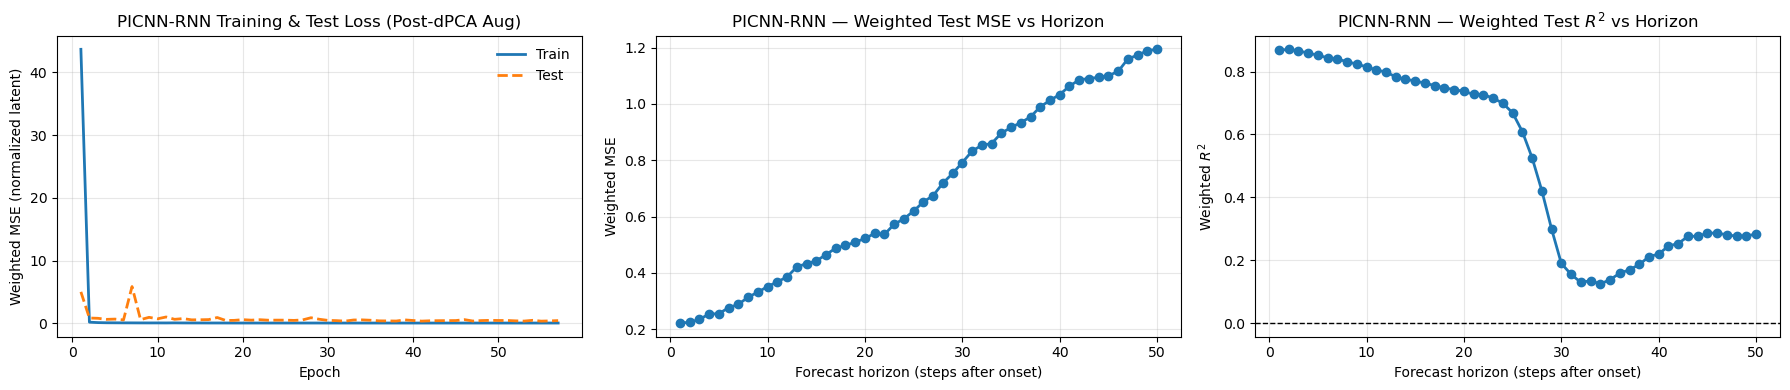

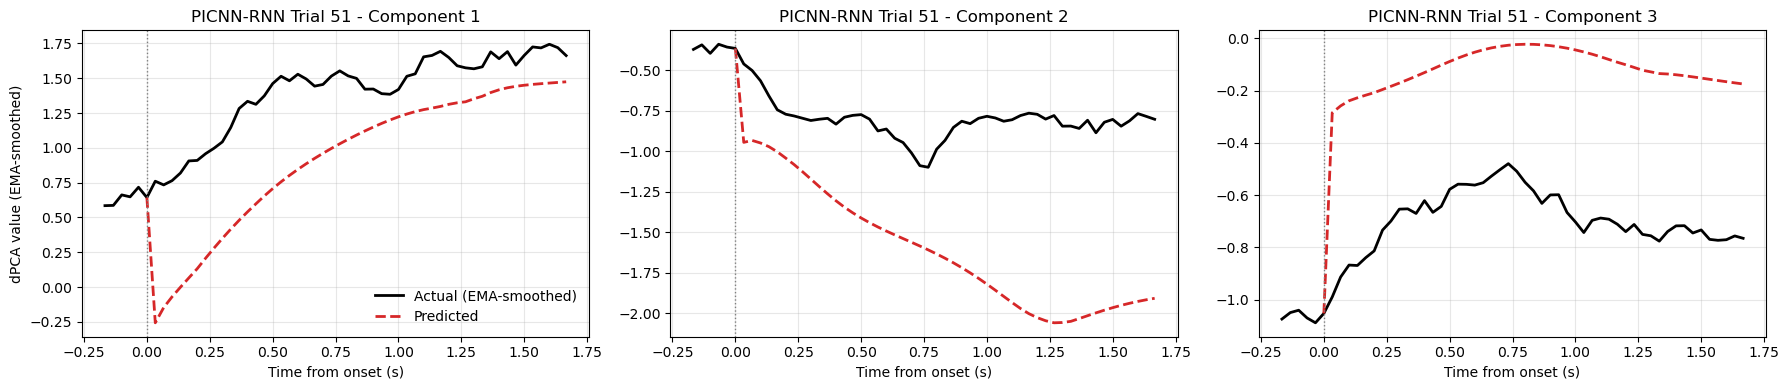

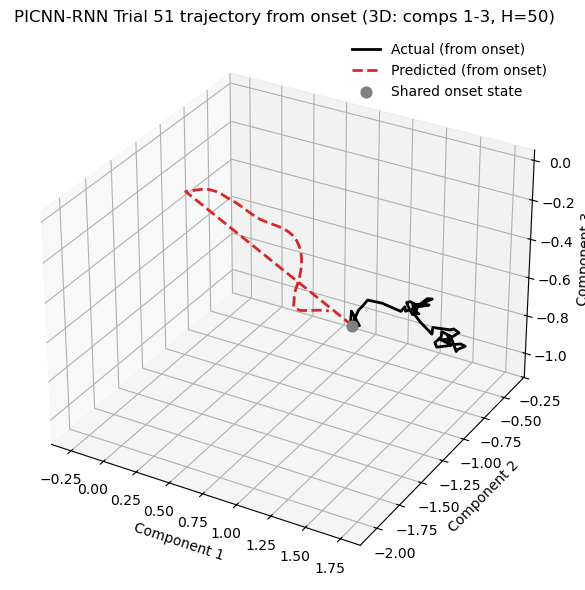

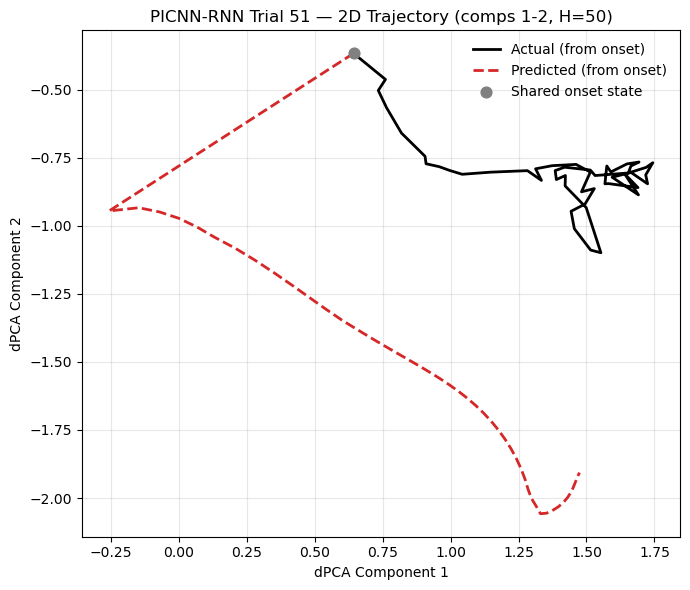


PICNN-RNN SUMMARY (Post-dPCA Augmentation)
Architecture: PICNN-RNN, encoder 2-layer tanh RNN (hidden=128),
  convex pathway: 3 layers (hidden=128), softplus non-neg weights
Parameters: 453,132

Timing:
Training time: 122.0013 s total (2.1404 s/epoch, 57 epochs)
Inference time (test batch of 33 trials,horizon =50): 0.009295 s
Inference time per trial: 0.000282 s

Convexity: 0 Jensen violations out of 10000 checks

Weighted horizon-wise metrics (first 5 shown):
t+01: weighted MSE=0.22178, weighted R2=0.86773
t+02: weighted MSE=0.22430, weighted R2=0.87082
t+03: weighted MSE=0.23463, weighted R2=0.86637
t+04: weighted MSE=0.25398, weighted R2=0.85871
t+05: weighted MSE=0.25475, weighted R2=0.85227

Averages across all 50 horizons:
  Weighted MSE: 0.68548
  Weighted R²:  0.52192


In [8]:
# =============================================================================
# ICRNN — Partially Input Convex RNN (PICNN-RNN) with Post-dPCA Augmentation
# =============================================================================
# Reuses data, datasets, and augmentation from cell 6 (already in kernel).

import copy as copy_picnn
import torch.nn.functional as F

# =============================================================================
# 1) PICNN-RNN Model
# =============================================================================

class PICRNNStimForecast(nn.Module):
    """
    Partially Input Convex RNN for stimulation forecasting.

    Convex in v (stimulation), non-convex in z (latent) and h (hidden).

    Key design choices (per Amos, Xu & Kolter 2017):
      - Only hidden-to-hidden weights in convex path are non-negative (softplus)
      - Weights from v_k into every layer are UNCONSTRAINED
      - Direct skip connection from v_k to output (affine = convex)
      - Autoregressive feedback uses z_base only (no v contribution)
        → guarantees convexity at ALL horizon steps

    Initialization note:
      Raw weights for softplus layers are initialised near -3.0 so that
      softplus(-3) ≈ 0.05, preventing the convex pathway from exploding
      when multiplied across multiple layers.
    """

    def __init__(self, latent_dim, stim_dim, hidden_dim=128, num_layers=2,
                 n_convex_layers=3, convex_hidden=128, dropout=0.3):
        super().__init__()
        self.latent_dim = latent_dim
        self.stim_dim = stim_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.n_convex_layers = n_convex_layers

        # --- Encoder: standard RNN (no convexity constraints) ---
        self.encoder = nn.RNN(
            input_size=latent_dim + stim_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            nonlinearity='tanh',
            dropout=dropout if num_layers > 1 else 0.0,
        )

        # --- Decoder non-convex pathway: RNNCell stack ---
        # Input is z_base only (NOT [z, v]) to keep h independent of v_k
        self.dec_cells = nn.ModuleList()
        self.dec_cells.append(nn.RNNCell(latent_dim, hidden_dim, nonlinearity='tanh'))
        for _ in range(1, num_layers):
            self.dec_cells.append(nn.RNNCell(hidden_dim, hidden_dim, nonlinearity='tanh'))
        self.dropout_layer = nn.Dropout(dropout)

        # --- Decoder convex pathway (per Amos et al. 2017) ---
        # W_in: UNCONSTRAINED weights from v_k at every layer
        # W_pos_raw: raw params -> softplus -> W_pos >= 0 (hidden-to-hidden only)
        # W_ctx: unconstrained context projection from h
        self.W_in = nn.ModuleList()          # unconstrained v_k -> layer
        self.W_pos_raw = nn.ParameterList()  # raw -> softplus -> non-neg passthrough
        self.W_ctx = nn.ModuleList()         # unconstrained h -> layer
        self.b_convex = nn.ParameterList()   # biases

        # Layer 0: input -> first hidden (no passthrough, just W_in)
        self.W_in.append(nn.Linear(stim_dim, convex_hidden))
        self.W_ctx.append(nn.Linear(hidden_dim, convex_hidden))
        self.b_convex.append(nn.Parameter(torch.zeros(convex_hidden)))

        # Layers 1..L_v-1: non-neg passthrough + unconstrained input injection
        for ell in range(1, n_convex_layers):
            self.W_pos_raw.append(
                nn.Parameter(torch.randn(convex_hidden, convex_hidden) * 0.01 - 3.0)  # softplus(-3) ≈ 0.05
            )
            self.W_in.append(nn.Linear(stim_dim, convex_hidden))
            self.W_ctx.append(nn.Linear(hidden_dim, convex_hidden))
            self.b_convex.append(nn.Parameter(torch.zeros(convex_hidden)))

        # --- Readout ---
        self.W_o = nn.Linear(hidden_dim, latent_dim)       # non-convex baseline
        self.W_ov_raw = nn.Parameter(                       # non-neg output weights
            torch.randn(latent_dim, convex_hidden) * 0.01 - 3.0  # softplus(-3) ≈ 0.05
        )
        self.b_ov = nn.Parameter(torch.zeros(latent_dim))

        # Unconstrained direct skip connection v_k -> z_hat
        self.W_direct = nn.Linear(stim_dim, latent_dim)

    def _pos(self, W_raw):
        """Non-negative weight via softplus reparametrisation."""
        return F.softplus(W_raw)

    def forward(self, context_z, context_v, future_v, target_z=None, teacher_forcing=0.0):
        B = context_z.shape[0]

        # --- Encode context (z and v together, unconstrained) ---
        enc_in = torch.cat([context_z, context_v], dim=-1)
        _, h_n = self.encoder(enc_in)  # h_n: (num_layers, B, hidden_dim)

        # Feed back the BASELINE state (without convex v contribution)
        prev_z_base = context_z[:, -1, :]
        preds = []
        H = future_v.shape[1]

        for k in range(H):
            v_k = future_v[:, k, :]     # (B, stim_dim)

            # (A) Non-convex pathway: update hidden state from z_base only
            h_in = prev_z_base
            h_new = []
            for layer_idx, cell in enumerate(self.dec_cells):
                h_l = cell(h_in, h_n[layer_idx])
                h_l = self.dropout_layer(h_l)
                h_new.append(h_l)
                h_in = h_l
            h_n = torch.stack(h_new, dim=0)
            h_top = h_n[-1]             # (B, hidden_dim)

            # (B) Convex pathway (proper ICNN)
            # Layer 0: unconstrained input mapping
            y = F.relu(
                self.W_in[0](v_k) + self.W_ctx[0](h_top) + self.b_convex[0]
            )

            # Layers 1..L_v-1: non-neg passthrough + unconstrained v_k injection
            for ell in range(1, self.n_convex_layers):
                W_pos = self._pos(self.W_pos_raw[ell - 1])  # non-neg hidden-to-hidden
                y = F.relu(
                    F.linear(y, W_pos) +             # non-negative passthrough
                    self.W_in[ell](v_k) +            # unconstrained v_k injection
                    self.W_ctx[ell](h_top) +         # unconstrained context
                    self.b_convex[ell]
                )

            # (C) Readout: baseline + convex contribution + direct skip
            z_base = self.W_o(h_top)
            W_ov_pos = self._pos(self.W_ov_raw)
            convex_contrib = F.linear(y, W_ov_pos, self.b_ov) + self.W_direct(v_k)

            pred_z = z_base + convex_contrib
            preds.append(pred_z.unsqueeze(1))

            # Feed back z_base (NOT pred_z) to keep h independent of v
            if self.training and target_z is not None and teacher_forcing > 0.0:
                mask = (torch.rand(B, device=pred_z.device) < teacher_forcing).float().unsqueeze(-1)
                prev_z_base = mask * target_z[:, k, :] + (1.0 - mask) * z_base
            else:
                prev_z_base = z_base

        return torch.cat(preds, dim=1)  # (B, H, latent_dim)

# =============================================================================
# 2) Train PICNN-RNN — AdamW + ReduceLROnPlateau + early stopping
# =============================================================================

model_picnn = PICRNNStimForecast(
    latent_dim=d_z, stim_dim=n_cells,
    hidden_dim=128, num_layers=2,
    n_convex_layers=3, convex_hidden=128,
    dropout=0.3,
).to(device)

n_params_picnn = sum(p.numel() for p in model_picnn.parameters() if p.requires_grad)
print(f"PICNN-RNN params: {n_params_picnn:,}")
print(f"Training on post-dPCA augmented data ({len(aug_train_ds)} samples)")
print("=" * 60)

optimizer_picnn = torch.optim.AdamW(model_picnn.parameters(), lr=1e-3, weight_decay=5e-4)
scheduler_picnn = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_picnn, mode='min', factor=0.5, patience=10, min_lr=1e-5
)

n_epochs_picnn = 200
early_stop_patience_picnn = 25
loss_history_picnn = []
test_loss_history_picnn = []

best_test_loss_picnn = float('inf')
best_model_state_picnn = None
epochs_no_improve_picnn = 0

train_t0_picnn = time.perf_counter()
for epoch in range(1, n_epochs_picnn + 1):
    model_picnn.train()
    running_loss_picnn = 0.0

    tf_ratio_picnn = 0.7 + (0.1 - 0.7) * ((epoch - 1) / max(n_epochs_picnn - 1, 1))

    for context_z_b, context_v_b, future_v_b, target_z_b in aug_train_loader:
        context_z_b = context_z_b.to(device)
        context_v_b = context_v_b.to(device)
        future_v_b = future_v_b.to(device)
        target_z_b = target_z_b.to(device)

        optimizer_picnn.zero_grad()
        pred_z_b = model_picnn(context_z_b, context_v_b, future_v_b,
                               target_z=target_z_b, teacher_forcing=tf_ratio_picnn)
        loss_picnn = weighted_mse_loss(pred_z_b, target_z_b, component_weights_t)
        loss_picnn.backward()
        torch.nn.utils.clip_grad_norm_(model_picnn.parameters(), 1.0)
        optimizer_picnn.step()

        running_loss_picnn += loss_picnn.item() * context_z_b.shape[0]

    epoch_loss_picnn = running_loss_picnn / len(aug_train_ds)
    loss_history_picnn.append(epoch_loss_picnn)

    # Compute test loss (open-loop, no teacher forcing)
    model_picnn.eval()
    with torch.no_grad():
        test_running_picnn = 0.0
        for context_z_b, context_v_b, future_v_b, target_z_b in test_loader:
            context_z_b = context_z_b.to(device)
            context_v_b = context_v_b.to(device)
            future_v_b = future_v_b.to(device)
            target_z_b = target_z_b.to(device)
            pred_z_b = model_picnn(context_z_b, context_v_b, future_v_b,
                                   target_z=None, teacher_forcing=0.0)
            test_running_picnn += weighted_mse_loss(pred_z_b, target_z_b, component_weights_t).item() * context_z_b.shape[0]
        current_test_loss_picnn = test_running_picnn / len(test_ds)
        test_loss_history_picnn.append(current_test_loss_picnn)

    # LR scheduler step
    scheduler_picnn.step(current_test_loss_picnn)

    # Early stopping check
    if current_test_loss_picnn < best_test_loss_picnn:
        best_test_loss_picnn = current_test_loss_picnn
        best_model_state_picnn = copy_picnn.deepcopy(model_picnn.state_dict())
        epochs_no_improve_picnn = 0
    else:
        epochs_no_improve_picnn += 1

    if epoch % 20 == 0 or epoch == 1:
        current_lr_picnn = optimizer_picnn.param_groups[0]['lr']
        print(f"Epoch {epoch:03d}/{n_epochs_picnn} | train_loss={epoch_loss_picnn:.6f} | "
              f"test_loss={current_test_loss_picnn:.6f} | lr={current_lr_picnn:.1e} | "
              f"tf={tf_ratio_picnn:.3f} | no_improve={epochs_no_improve_picnn}")

    if epochs_no_improve_picnn >= early_stop_patience_picnn:
        print(f"\nEarly stopping at epoch {epoch} (no improvement for {early_stop_patience_picnn} epochs).")
        print(f"Best test loss: {best_test_loss_picnn:.6f}")
        break

training_time_picnn = time.perf_counter() - train_t0_picnn
actual_epochs_picnn = epoch

# Restore best model
if best_model_state_picnn is not None:
    model_picnn.load_state_dict(best_model_state_picnn)
    print(f"Restored best model weights (test loss = {best_test_loss_picnn:.6f})")

# =============================================================================
# 3) Empirical convexity verification (Jensen inequality — ALL steps)
# =============================================================================

print("\n" + "=" * 60)
print("EMPIRICAL CONVEXITY VERIFICATION (ALL HORIZON STEPS)")
print("=" * 60)

model_picnn.eval()
n_checks = 200
violations_per_step = np.zeros(horizon, dtype=int)
max_violation_per_step = np.zeros(horizon)

# Use a fixed context from trial 51
cz_single_cv = torch.from_numpy(z_trial_n[51, :context_len, :]).unsqueeze(0).to(device)
cv_single_cv = torch.from_numpy(v[51, :context_len, :]).unsqueeze(0).to(device)

with torch.no_grad():
    for _ in range(n_checks):
        # Sample two random stimulation sequences
        v1 = torch.rand(1, horizon, n_cells, device=device)
        v2 = torch.rand(1, horizon, n_cells, device=device)
        lam = torch.rand(1, device=device).item()

        v_mix = lam * v1 + (1 - lam) * v2

        # f(lambda*v1 + (1-lambda)*v2)
        pred_mix = model_picnn(cz_single_cv, cv_single_cv, v_mix,
                               target_z=None, teacher_forcing=0.0)
        # lambda*f(v1) + (1-lambda)*f(v2)
        pred_v1 = model_picnn(cz_single_cv, cv_single_cv, v1,
                              target_z=None, teacher_forcing=0.0)
        pred_v2 = model_picnn(cz_single_cv, cv_single_cv, v2,
                              target_z=None, teacher_forcing=0.0)
        convex_comb = lam * pred_v1 + (1 - lam) * pred_v2

        # Check at EVERY horizon step: f(v_mix)_k <= lam*f(v1)_k + (1-lam)*f(v2)_k
        for step_k in range(horizon):
            diff_k = (pred_mix[:, step_k, :] - convex_comb[:, step_k, :]).max().item()
            if diff_k > 1e-5:
                violations_per_step[step_k] += 1
            max_violation_per_step[step_k] = max(max_violation_per_step[step_k], diff_k)

total_violations = int(violations_per_step.sum())
print(f"Jensen inequality checks: {n_checks} pairs x {horizon} steps = {n_checks * horizon} total")
print(f"Total violations (tolerance 1e-5): {total_violations}/{n_checks * horizon}")
print(f"\nPer-step breakdown:")
print(f"{'Step':>6s}  {'Violations':>10s}  {'Max Violation':>14s}")
for step_k in range(horizon):
    flag = " !!" if violations_per_step[step_k] > 0 else " ok"
    print(f"  k={step_k+1:02d}  {violations_per_step[step_k]:>10d}  {max_violation_per_step[step_k]:>14.2e}{flag}")

if total_violations == 0:
    print("\nConvexity in v verified at ALL horizon steps!")
else:
    print(f"\n{total_violations} violations detected — likely numerical precision; check magnitudes.")

# =============================================================================
# 4) Evaluate weighted horizon-wise metrics on test set
# =============================================================================

model_picnn.eval()
with torch.no_grad():
    (context_z_t_pic, context_v_t_pic, future_v_t_pic, target_z_t_pic) = next(iter(test_loader))
    context_z_t_pic = context_z_t_pic.to(device)
    context_v_t_pic = context_v_t_pic.to(device)
    future_v_t_pic = future_v_t_pic.to(device)

    if device.type == 'cuda':
        torch.cuda.synchronize()
    infer_t0_pic = time.perf_counter()
    pred_z_t_pic = model_picnn(context_z_t_pic, context_v_t_pic, future_v_t_pic,
                               target_z=None, teacher_forcing=0.0)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    inference_time_picnn = time.perf_counter() - infer_t0_pic

pred_z_t_pic = pred_z_t_pic.cpu().numpy()
target_z_t_pic = target_z_t_pic.numpy()

pred_z_pic = pred_z_t_pic * z_std + z_mean
target_z_pic = target_z_t_pic * z_std + z_mean

weighted_mse_by_h_pic = []
weighted_r2_by_h_pic = []

for h in range(horizon):
    y_true_h = target_z_pic[:, h, :]
    y_pred_h = pred_z_pic[:, h, :]

    mse_per_comp = np.mean((y_pred_h - y_true_h) ** 2, axis=0)
    w_mse = float(np.sum(component_weights * mse_per_comp))

    r2_per_comp = np.zeros(d_z, dtype=np.float64)
    for comp in range(d_z):
        if np.var(y_true_h[:, comp]) < 1e-12:
            r2_per_comp[comp] = 0.0
        else:
            r2_per_comp[comp] = r2_score(y_true_h[:, comp], y_pred_h[:, comp])
    w_r2 = float(np.sum(component_weights * r2_per_comp))

    weighted_mse_by_h_pic.append(w_mse)
    weighted_r2_by_h_pic.append(w_r2)

# =============================================================================
# 5) Plot training curve + weighted horizon-wise MSE and R²
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(np.arange(1, actual_epochs_picnn + 1), loss_history_picnn, lw=2, label='Train')
axes[0].plot(np.arange(1, actual_epochs_picnn + 1), test_loss_history_picnn, lw=2, ls='--', label='Test')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Weighted MSE (normalized latent)')
axes[0].set_title('PICNN-RNN Training & Test Loss (Post-dPCA Aug)')
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.3)

axes[1].plot(horizons, weighted_mse_by_h_pic, marker='o', lw=2)
axes[1].set_xlabel('Forecast horizon (steps after onset)')
axes[1].set_ylabel('Weighted MSE')
axes[1].set_title('PICNN-RNN — Weighted Test MSE vs Horizon')
axes[1].grid(alpha=0.3)

axes[2].plot(horizons, weighted_r2_by_h_pic, marker='o', lw=2)
axes[2].axhline(0.0, color='k', ls='--', lw=1)
axes[2].set_xlabel('Forecast horizon (steps after onset)')
axes[2].set_ylabel('Weighted $R^2$')
axes[2].set_title('PICNN-RNN — Weighted Test $R^2$ vs Horizon')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# =============================================================================
# 6) Trial 51 trajectories: include 5 pre-onset timesteps
# =============================================================================

trial_id_pic = 51
pre_steps_pic = 5

context_z_single_pic = torch.from_numpy(z_trial_n[trial_id_pic, :context_len, :]).unsqueeze(0).to(device)
context_v_single_pic = torch.from_numpy(v[trial_id_pic, :context_len, :]).unsqueeze(0).to(device)
future_v_single_pic = torch.from_numpy(v[trial_id_pic, zero_idx + 1:zero_idx + 1 + horizon, :]).unsqueeze(0).to(device)
with torch.no_grad():
    pred_single_n_pic = model_picnn(context_z_single_pic, context_v_single_pic, future_v_single_pic,
                                     target_z=None, teacher_forcing=0.0)

pred_single_pic = pred_single_n_pic.squeeze(0).cpu().numpy() * z_std.squeeze((0, 1)) + z_mean.squeeze((0, 1))

start_idx_pic = zero_idx - pre_steps_pic
end_idx_pic = zero_idx + 1 + horizon
t_window_pic = time_axis[start_idx_pic:end_idx_pic]
true_window_pic = z_trial[trial_id_pic, start_idx_pic:end_idx_pic, :]

pred_window_pic = np.full((pre_steps_pic + 1 + horizon, d_z), np.nan, dtype=np.float32)
pred_window_pic[pre_steps_pic, :] = true_window_pic[pre_steps_pic, :]  # onset anchor
pred_window_pic[pre_steps_pic + 1:, :] = pred_single_pic

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=True)
for comp in range(3):
    axes[comp].plot(t_window_pic, true_window_pic[:, comp], lw=2, label='Actual (EMA-smoothed)', color='black')
    axes[comp].plot(t_window_pic, pred_window_pic[:, comp], lw=2, ls='--', label='Predicted', color='tab:red')
    axes[comp].axvline(0.0, color='gray', ls=':', lw=1)
    axes[comp].set_title(f'PICNN-RNN Trial {trial_id_pic} - Component {comp + 1}')
    axes[comp].set_xlabel('Time from onset (s)')
    axes[comp].grid(alpha=0.3)

axes[0].set_ylabel('dPCA value (EMA-smoothed)')
axes[0].legend(frameon=False)
plt.tight_layout()
plt.show()

# 3D trajectory plot (components 1-3) — both start at onset
true_post_pic = z_trial[trial_id_pic, zero_idx + 1:zero_idx + 1 + horizon, :]
onset_state_pic = z_trial[trial_id_pic, zero_idx, :]

true_from_onset_pic = np.vstack([onset_state_pic[None, :], true_post_pic])
pred_from_onset_pic = np.vstack([onset_state_pic[None, :], pred_single_pic])

fig = plt.figure(figsize=(7, 6))
ax3d_pic = fig.add_subplot(111, projection='3d')
ax3d_pic.plot(true_from_onset_pic[:, 0], true_from_onset_pic[:, 1], true_from_onset_pic[:, 2],
              color='black', lw=2, label='Actual (from onset)')
ax3d_pic.plot(pred_from_onset_pic[:, 0], pred_from_onset_pic[:, 1], pred_from_onset_pic[:, 2],
              color='tab:red', lw=2, ls='--', label='Predicted (from onset)')
ax3d_pic.scatter(onset_state_pic[0], onset_state_pic[1], onset_state_pic[2],
                 color='gray', s=60, zorder=5, label='Shared onset state')
ax3d_pic.set_title(f'PICNN-RNN Trial {trial_id_pic} trajectory from onset (3D: comps 1-3, H={horizon})')
ax3d_pic.set_xlabel('Component 1')
ax3d_pic.set_ylabel('Component 2')
ax3d_pic.set_zlabel('Component 3')
ax3d_pic.legend(frameon=False)
plt.tight_layout()
plt.show()

# 2D trajectory (components 1 & 2) — both start at onset
fig, ax2d_pic = plt.subplots(figsize=(7, 6))
ax2d_pic.plot(true_from_onset_pic[:, 0], true_from_onset_pic[:, 1],
              color='black', lw=2, label='Actual (from onset)')
ax2d_pic.plot(pred_from_onset_pic[:, 0], pred_from_onset_pic[:, 1],
              color='tab:red', lw=2, ls='--', label='Predicted (from onset)')
ax2d_pic.scatter(onset_state_pic[0], onset_state_pic[1],
                 color='gray', s=60, zorder=5, label='Shared onset state')
ax2d_pic.set_title(f'PICNN-RNN Trial {trial_id_pic} — 2D Trajectory (comps 1-2, H={horizon})')
ax2d_pic.set_xlabel('dPCA Component 1')
ax2d_pic.set_ylabel('dPCA Component 2')
ax2d_pic.legend(frameon=False)
ax2d_pic.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# =============================================================================
# 7) Summary
# =============================================================================

print('\n' + '=' * 70)
print('PICNN-RNN SUMMARY (Post-dPCA Augmentation)')
print('=' * 70)
print(f"Architecture: PICNN-RNN, encoder 2-layer tanh RNN (hidden=128),")
print(f"  convex pathway: {model_picnn.n_convex_layers} layers (hidden=128), softplus non-neg weights")
print(f"Parameters: {n_params_picnn:,}")

print(f'\nTiming:')
print(f"Training time: {training_time_picnn:.4f} s total ({training_time_picnn / actual_epochs_picnn:.4f} s/epoch, {actual_epochs_picnn} epochs)")
print(f"Inference time (test batch of {len(test_ds)} trials,horizon ={horizon}): {inference_time_picnn:.6f} s")
print(f"Inference time per trial: {inference_time_picnn / max(len(test_ds), 1):.6f} s")

print(f'\nConvexity: {total_violations} Jensen violations out of {n_checks * horizon} checks')

print('\nWeighted horizon-wise metrics (first 5 shown):')
for h in range(min(5, horizon)):
    print(f"t+{h+1:02d}: weighted MSE={weighted_mse_by_h_pic[h]:.5f}, weighted R2={weighted_r2_by_h_pic[h]:.5f}")

avg_r2_pic = np.mean(weighted_r2_by_h_pic)
avg_mse_pic = np.mean(weighted_mse_by_h_pic)
print(f"\nAverages across all {horizon} horizons:")
print(f"  Weighted MSE: {avg_mse_pic:.5f}")
print(f"  Weighted R²:  {avg_r2_pic:.5f}")

Top-3 dPCA latent shape: (162, 420, 3)
d_z_top3=3, component weights: [0.8440017  0.07134481 0.08465354]
Top-3 train samples: 1769, test samples: 33
PICRNN (top-3) params: 426,510
Epoch 001/200 | train=20.716174 | test=1.194321 | lr=1.0e-03 | tf=0.700 | no_improve=0
Epoch 020/200 | train=0.042247 | test=0.532593 | lr=5.0e-04 | tf=0.643 | no_improve=14
Epoch 040/200 | train=0.040155 | test=0.447475 | lr=2.5e-04 | tf=0.582 | no_improve=16
Epoch 060/200 | train=0.041378 | test=0.561778 | lr=2.5e-04 | tf=0.522 | no_improve=10
Epoch 080/200 | train=0.045565 | test=0.329521 | lr=6.3e-05 | tf=0.462 | no_improve=0
Epoch 100/200 | train=0.048101 | test=0.320562 | lr=3.1e-05 | tf=0.402 | no_improve=0
Epoch 120/200 | train=0.054621 | test=0.313576 | lr=1.6e-05 | tf=0.341 | no_improve=6
Epoch 140/200 | train=0.062396 | test=0.307461 | lr=1.0e-05 | tf=0.281 | no_improve=6

Early stopping at epoch 159 (no improvement for 25 epochs).
Best test loss: 0.296623
Restored best model (test loss = 0.296623)

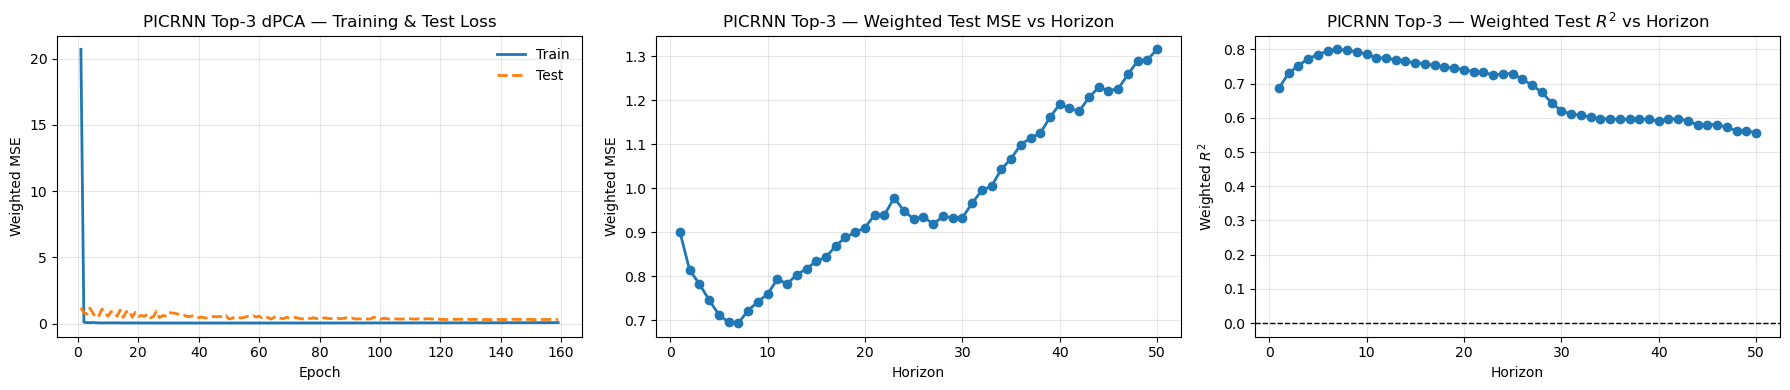

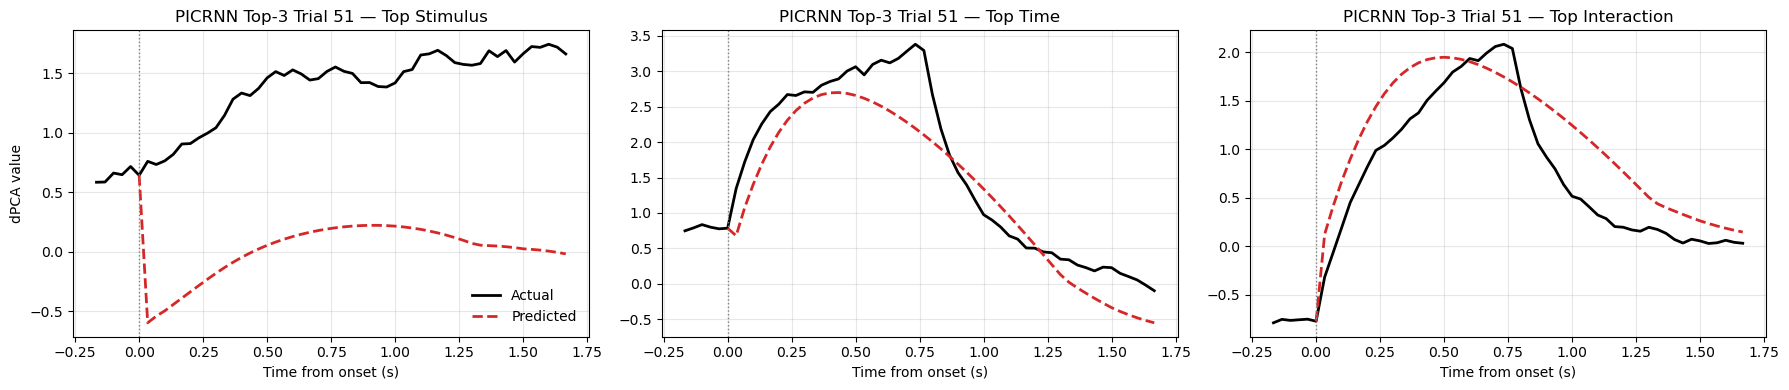

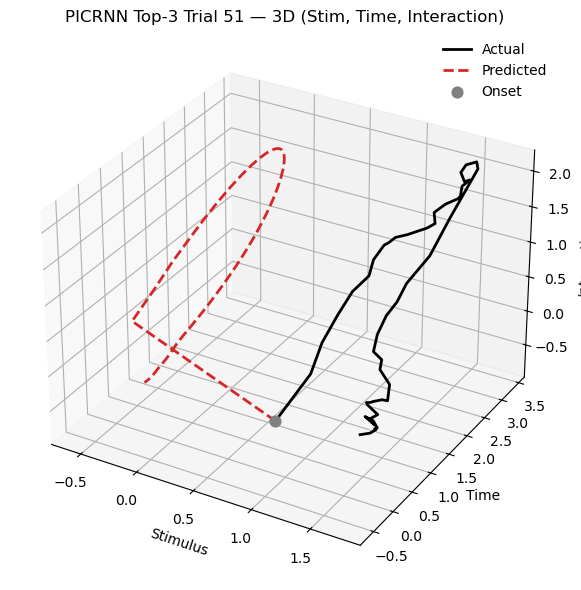

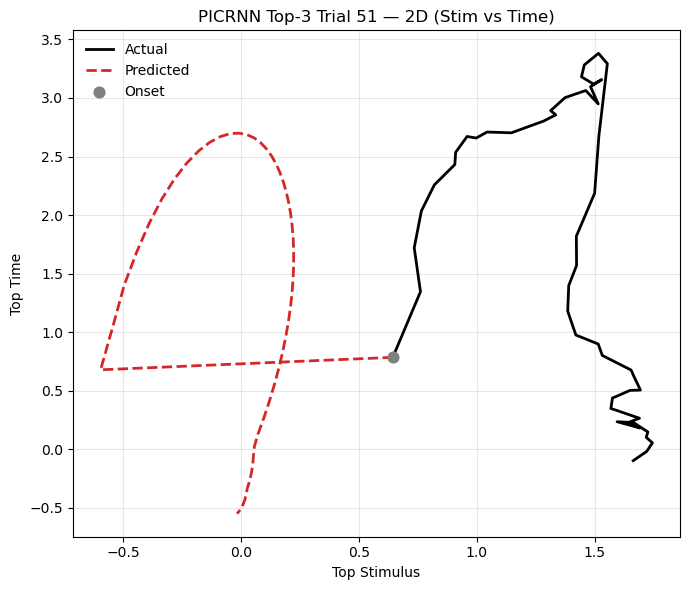


PICRNN TOP-3 dPCA SUMMARY
Latent dim: 3 (top stimulus + top time + top interaction)
Parameters: 426,510
Training: 340.31s (159 epochs)
Inference: 0.009336s (33 trials)
Convexity: 0 violations / 10000

Weighted horizon metrics (first     5):
  t+01: wMSE=0.90111, wR²=0.68659
  t+02: wMSE=0.81429, wR²=0.73089
  t+03: wMSE=0.78307, wR²=0.75235
  t+04: wMSE=0.74634, wR²=0.77314
  t+05: wMSE=0.71333, wR²=0.78470

Averages across 50 horizons:
  Weighted MSE: 0.97140
  Weighted R²:  0.68128


In [8]:
# =============================================================================
# PICRNN on TOP-3 dPCA COMPONENTS (1st stimulus, 1st time, 1st interaction)
# =============================================================================

import copy as copy_top3
import torch.nn.functional as F

# ---- 0) Rebuild latent trajectories with only top-3 dPCA components --------
z_trial_top3 = np.concatenate(
    [z_all['s'][:1], z_all['t'][:1], z_all['st'][:1]], axis=0
)  # (3, n_trials, T)
z_trial_top3 = np.transpose(z_trial_top3, (1, 2, 0)).astype(np.float32)  # (n_trials, T, 3)

# Apply same EMA smoothing
z_trial_top3 = apply_ema(z_trial_top3, alpha=EMA_ALPHA)
print(f"Top-3 dPCA latent shape: {z_trial_top3.shape}")

d_z_top3 = z_trial_top3.shape[-1]  # 3

# Normalization from training split only
z_train_top3 = z_trial_top3[train_indices]
z_mean_top3 = z_train_top3.mean(axis=(0, 1), keepdims=True)
z_std_top3 = z_train_top3.std(axis=(0, 1), keepdims=True) + 1e-6
z_trial_n_top3 = (z_trial_top3 - z_mean_top3) / z_std_top3

# Variance contribution weights per component (from train set)
comp_var_top3 = z_train_top3.var(axis=(0, 1))
comp_weights_top3 = comp_var_top3 / (comp_var_top3.sum() + 1e-12)
comp_weights_top3_t = torch.from_numpy(comp_weights_top3).float().to(device)

# Per-component noise std for augmentation
z_train_n_top3 = z_trial_n_top3[train_indices]
z_comp_std_top3 = z_train_n_top3.std(axis=(0, 1))
noise_std_top3 = (noise_frac * z_comp_std_top3).astype(np.float32)

print(f"d_z_top3={d_z_top3}, component weights: {comp_weights_top3}")

# ---- 1) Datasets using top-3 latents (stimulus vector v unchanged) ----------

class OnsetForecastDatasetTop3(Dataset):
    """Clean dataset for test evaluation (top-3 dPCA components)."""
    def __init__(self, trial_indices):
        self.trial_indices = np.array(trial_indices)
    def __len__(self):
        return len(self.trial_indices)
    def __getitem__(self, idx):
        tr = self.trial_indices[idx]
        context_z = z_trial_n_top3[tr, :context_len, :]
        context_v = v[tr, :context_len, :]
        future_v = v[tr, zero_idx + 1:zero_idx + 1 + horizon, :]
        target_z = z_trial_n_top3[tr, zero_idx + 1:zero_idx + 1 + horizon, :]
        return (
            torch.from_numpy(context_z),
            torch.from_numpy(context_v),
            torch.from_numpy(future_v),
            torch.from_numpy(target_z),
        )

class AugOnsetTop3(Dataset):
    """Training dataset with peri-onset augmentation (top-3 dPCA)."""
    def __init__(self, trial_indices, stim_mask, n_augment, noise_std, aug_start, aug_end):
        self.noise_std = noise_std
        self.aug_start = aug_start
        self.aug_end = aug_end
        self.items = []
        for i, tr in enumerate(trial_indices):
            self.items.append((tr, 0))
            if stim_mask[i]:
                for k in range(1, n_augment + 1):
                    self.items.append((tr, k))
    def __len__(self):
        return len(self.items)
    def __getitem__(self, idx):
        tr, copy_idx = self.items[idx]
        context_z = z_trial_n_top3[tr, :context_len, :].copy()
        context_v = v[tr, :context_len, :]
        future_v  = v[tr, zero_idx + 1:zero_idx + 1 + horizon, :]
        target_z  = z_trial_n_top3[tr, zero_idx + 1:zero_idx + 1 + horizon, :].copy()
        if copy_idx > 0:
            ctx_noise_start = self.aug_start
            ctx_noise_end = min(self.aug_end, context_len)
            if ctx_noise_end > ctx_noise_start:
                n_ctx = ctx_noise_end - ctx_noise_start
                context_z[ctx_noise_start:ctx_noise_end, :] += (
                    np.random.randn(n_ctx, len(self.noise_std)).astype(np.float32) * self.noise_std
                )
            tgt_global_start = zero_idx + 1
            tgt_global_end = zero_idx + 1 + horizon
            tgt_noise_start = max(self.aug_start, tgt_global_start) - tgt_global_start
            tgt_noise_end = min(self.aug_end, tgt_global_end) - tgt_global_start
            if tgt_noise_end > tgt_noise_start:
                n_tgt = tgt_noise_end - tgt_noise_start
                target_z[tgt_noise_start:tgt_noise_end, :] += (
                    np.random.randn(n_tgt, len(self.noise_std)).astype(np.float32) * self.noise_std
                )
        return (
            torch.from_numpy(context_z),
            torch.from_numpy(context_v),
            torch.from_numpy(future_v),
            torch.from_numpy(target_z),
        )

aug_train_ds_top3 = AugOnsetTop3(
    train_indices, stim_mask=train_stim_mask, n_augment=n_augment,
    noise_std=noise_std_top3, aug_start=aug_start, aug_end=aug_end,
)
aug_train_loader_top3 = DataLoader(aug_train_ds_top3, batch_size=32, shuffle=True)
test_ds_top3 = OnsetForecastDatasetTop3(test_indices)
test_loader_top3 = DataLoader(test_ds_top3, batch_size=len(test_ds_top3), shuffle=False)

print(f"Top-3 train samples: {len(aug_train_ds_top3)}, test samples: {len(test_ds_top3)}")

# ---- 2) PICRNN model (same architecture, latent_dim=3) ----------------------

model_picnn_top3 = PICRNNStimForecast(
    latent_dim=d_z_top3, stim_dim=n_cells,
    hidden_dim=128, num_layers=2,
    n_convex_layers=3, convex_hidden=128,
    dropout=0.3,
).to(device)

n_params_top3 = sum(p.numel() for p in model_picnn_top3.parameters() if p.requires_grad)
print(f"PICRNN (top-3) params: {n_params_top3:,}")
print("=" * 60)

# ---- 3) Train ---------------------------------------------------------------

optimizer_top3 = torch.optim.AdamW(model_picnn_top3.parameters(), lr=1e-3, weight_decay=5e-4)
scheduler_top3 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_top3, mode='min', factor=0.5, patience=10, min_lr=1e-5
)

n_epochs_top3 = 200
early_stop_patience_top3 = 25
loss_hist_top3 = []
test_loss_hist_top3 = []

best_test_loss_top3 = float('inf')
best_state_top3 = None
no_improve_top3 = 0

train_t0_top3 = time.perf_counter()
for epoch in range(1, n_epochs_top3 + 1):
    model_picnn_top3.train()
    running = 0.0
    tf = 0.7 + (0.1 - 0.7) * ((epoch - 1) / max(n_epochs_top3 - 1, 1))

    for cz, cv, fv, tz in aug_train_loader_top3:
        cz, cv, fv, tz = cz.to(device), cv.to(device), fv.to(device), tz.to(device)
        optimizer_top3.zero_grad()
        pz = model_picnn_top3(cz, cv, fv, target_z=tz, teacher_forcing=tf)
        loss = weighted_mse_loss(pz, tz, comp_weights_top3_t)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_picnn_top3.parameters(), 1.0)
        optimizer_top3.step()
        running += loss.item() * cz.shape[0]

    epoch_loss = running / len(aug_train_ds_top3)
    loss_hist_top3.append(epoch_loss)

    model_picnn_top3.eval()
    with torch.no_grad():
        test_run = 0.0
        for cz, cv, fv, tz in test_loader_top3:
            cz, cv, fv, tz = cz.to(device), cv.to(device), fv.to(device), tz.to(device)
            pz = model_picnn_top3(cz, cv, fv, target_z=None, teacher_forcing=0.0)
            test_run += weighted_mse_loss(pz, tz, comp_weights_top3_t).item() * cz.shape[0]
        cur_test = test_run / len(test_ds_top3)
        test_loss_hist_top3.append(cur_test)

    scheduler_top3.step(cur_test)

    if cur_test < best_test_loss_top3:
        best_test_loss_top3 = cur_test
        best_state_top3 = copy_top3.deepcopy(model_picnn_top3.state_dict())
        no_improve_top3 = 0
    else:
        no_improve_top3 += 1

    if epoch % 20 == 0 or epoch == 1:
        lr_now = optimizer_top3.param_groups[0]['lr']
        print(f"Epoch {epoch:03d}/{n_epochs_top3} | train={epoch_loss:.6f} | test={cur_test:.6f} | "
              f"lr={lr_now:.1e} | tf={tf:.3f} | no_improve={no_improve_top3}")

    if no_improve_top3 >= early_stop_patience_top3:
        print(f"\nEarly stopping at epoch {epoch} (no improvement for {early_stop_patience_top3} epochs).")
        print(f"Best test loss: {best_test_loss_top3:.6f}")
        break

training_time_top3 = time.perf_counter() - train_t0_top3
actual_epochs_top3 = epoch

if best_state_top3 is not None:
    model_picnn_top3.load_state_dict(best_state_top3)
    print(f"Restored best model (test loss = {best_test_loss_top3:.6f})")

# ---- 4) Convexity verification -----------------------------------------------

print("\n" + "=" * 60)
print("EMPIRICAL CONVEXITY VERIFICATION (TOP-3, ALL HORIZON STEPS)")
print("=" * 60)

model_picnn_top3.eval()
n_checks_t3 = 200
viol_per_step_t3 = np.zeros(horizon, dtype=int)
max_viol_per_step_t3 = np.zeros(horizon)

cz_cv_t3 = torch.from_numpy(z_trial_n_top3[51, :context_len, :]).unsqueeze(0).to(device)
cv_cv_t3 = torch.from_numpy(v[51, :context_len, :]).unsqueeze(0).to(device)

with torch.no_grad():
    for _ in range(n_checks_t3):
        v1 = torch.rand(1, horizon, n_cells, device=device)
        v2 = torch.rand(1, horizon, n_cells, device=device)
        lam = torch.rand(1, device=device).item()
        v_mix = lam * v1 + (1 - lam) * v2
        pm = model_picnn_top3(cz_cv_t3, cv_cv_t3, v_mix, target_z=None, teacher_forcing=0.0)
        p1 = model_picnn_top3(cz_cv_t3, cv_cv_t3, v1, target_z=None, teacher_forcing=0.0)
        p2 = model_picnn_top3(cz_cv_t3, cv_cv_t3, v2, target_z=None, teacher_forcing=0.0)
        cc = lam * p1 + (1 - lam) * p2
        for sk in range(horizon):
            diff = (pm[:, sk, :] - cc[:, sk, :]).max().item()
            if diff > 1e-5:
                viol_per_step_t3[sk] += 1
            max_viol_per_step_t3[sk] = max(max_viol_per_step_t3[sk], diff)

tot_viol_t3 = int(viol_per_step_t3.sum())
print(f"Jensen checks: {n_checks_t3} pairs x {horizon} steps = {n_checks_t3 * horizon}")
print(f"Violations (tol 1e-5): {tot_viol_t3}/{n_checks_t3 * horizon}")
for sk in range(horizon):
    flag = " !!" if viol_per_step_t3[sk] > 0 else " ok"
    print(f"  k={sk+1:02d}  violations={viol_per_step_t3[sk]:>4d}  max_viol={max_viol_per_step_t3[sk]:.2e}{flag}")
if tot_viol_t3 == 0:
    print("\nConvexity in v verified at ALL horizon steps!")

# ---- 5) Evaluate weighted horizon-wise metrics on test set -------------------

model_picnn_top3.eval()
with torch.no_grad():
    cz_e, cv_e, fv_e, tz_e = next(iter(test_loader_top3))
    cz_e, cv_e, fv_e = cz_e.to(device), cv_e.to(device), fv_e.to(device)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    t0_inf = time.perf_counter()
    pz_e = model_picnn_top3(cz_e, cv_e, fv_e, target_z=None, teacher_forcing=0.0)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    inf_time_top3 = time.perf_counter() - t0_inf

pz_e_np = pz_e.cpu().numpy() * z_std_top3 + z_mean_top3
tz_e_np = tz_e.numpy() * z_std_top3 + z_mean_top3

wmse_h_t3 = []
wr2_h_t3 = []
for h in range(horizon):
    yt = tz_e_np[:, h, :]
    yp = pz_e_np[:, h, :]
    mse_c = np.mean((yp - yt) ** 2, axis=0)
    w_mse = float(np.sum(comp_weights_top3 * mse_c))
    r2_c = np.zeros(d_z_top3)
    for c in range(d_z_top3):
        if np.var(yt[:, c]) < 1e-12:
            r2_c[c] = 0.0
        else:
            r2_c[c] = r2_score(yt[:, c], yp[:, c])
    w_r2 = float(np.sum(comp_weights_top3 * r2_c))
    wmse_h_t3.append(w_mse)
    wr2_h_t3.append(w_r2)

# ---- 6) Plots ----------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].plot(np.arange(1, actual_epochs_top3 + 1), loss_hist_top3, lw=2, label='Train')
axes[0].plot(np.arange(1, actual_epochs_top3 + 1), test_loss_hist_top3, lw=2, ls='--', label='Test')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Weighted MSE')
axes[0].set_title('PICRNN Top-3 dPCA — Training & Test Loss')
axes[0].legend(frameon=False); axes[0].grid(alpha=0.3)

axes[1].plot(horizons, wmse_h_t3, marker='o', lw=2)
axes[1].set_xlabel('Horizon'); axes[1].set_ylabel('Weighted MSE')
axes[1].set_title('PICRNN Top-3 — Weighted Test MSE vs Horizon'); axes[1].grid(alpha=0.3)

axes[2].plot(horizons, wr2_h_t3, marker='o', lw=2)
axes[2].axhline(0.0, color='k', ls='--', lw=1)
axes[2].set_xlabel('Horizon'); axes[2].set_ylabel('Weighted $R^2$')
axes[2].set_title('PICRNN Top-3 — Weighted Test $R^2$ vs Horizon'); axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ---- 7) Trial 51 trajectories -----------------------------------------------

trial_id_t3 = 51
pre_steps_t3 = 5
cz_s = torch.from_numpy(z_trial_n_top3[trial_id_t3, :context_len, :]).unsqueeze(0).to(device)
cv_s = torch.from_numpy(v[trial_id_t3, :context_len, :]).unsqueeze(0).to(device)
fv_s = torch.from_numpy(v[trial_id_t3, zero_idx + 1:zero_idx + 1 + horizon, :]).unsqueeze(0).to(device)
with torch.no_grad():
    pred_s = model_picnn_top3(cz_s, cv_s, fv_s, target_z=None, teacher_forcing=0.0)

pred_s_np = pred_s.squeeze(0).cpu().numpy() * z_std_top3.squeeze((0, 1)) + z_mean_top3.squeeze((0, 1))

start_t3 = zero_idx - pre_steps_t3
end_t3 = zero_idx + 1 + horizon
t_win = time_axis[start_t3:end_t3]
true_win = z_trial_top3[trial_id_t3, start_t3:end_t3, :]

pred_win = np.full((pre_steps_t3 + 1 + horizon, d_z_top3), np.nan, dtype=np.float32)
pred_win[pre_steps_t3, :] = true_win[pre_steps_t3, :]
pred_win[pre_steps_t3 + 1:, :] = pred_s_np

comp_labels = ['Top Stimulus', 'Top Time', 'Top Interaction']
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=True)
for c in range(3):
    axes[c].plot(t_win, true_win[:, c], lw=2, label='Actual', color='black')
    axes[c].plot(t_win, pred_win[:, c], lw=2, ls='--', label='Predicted', color='tab:red')
    axes[c].axvline(0.0, color='gray', ls=':', lw=1)
    axes[c].set_title(f'PICRNN Top-3 Trial {trial_id_t3} — {comp_labels[c]}')
    axes[c].set_xlabel('Time from onset (s)'); axes[c].grid(alpha=0.3)
axes[0].set_ylabel('dPCA value'); axes[0].legend(frameon=False)
plt.tight_layout(); plt.show()

# 3D trajectory
true_post_t3 = z_trial_top3[trial_id_t3, zero_idx + 1:zero_idx + 1 + horizon, :]
onset_t3 = z_trial_top3[trial_id_t3, zero_idx, :]
true_from_o = np.vstack([onset_t3[None, :], true_post_t3])
pred_from_o = np.vstack([onset_t3[None, :], pred_s_np])

fig = plt.figure(figsize=(7, 6))
ax3 = fig.add_subplot(111, projection='3d')
ax3.plot(true_from_o[:, 0], true_from_o[:, 1], true_from_o[:, 2], color='black', lw=2, label='Actual')
ax3.plot(pred_from_o[:, 0], pred_from_o[:, 1], pred_from_o[:, 2], color='tab:red', lw=2, ls='--', label='Predicted')
ax3.scatter(onset_t3[0], onset_t3[1], onset_t3[2], color='gray', s=60, zorder=5, label='Onset')
ax3.set_title(f'PICRNN Top-3 Trial {trial_id_t3} — 3D (Stim, Time, Interaction)')
ax3.set_xlabel('Stimulus'); ax3.set_ylabel('Time'); ax3.set_zlabel('Interaction')
ax3.legend(frameon=False); plt.tight_layout(); plt.show()

# 2D trajectory (Stimulus vs Time)
fig, ax2 = plt.subplots(figsize=(7, 6))
ax2.plot(true_from_o[:, 0], true_from_o[:, 1], color='black', lw=2, label='Actual')
ax2.plot(pred_from_o[:, 0], pred_from_o[:, 1], color='tab:red', lw=2, ls='--', label='Predicted')
ax2.scatter(onset_t3[0], onset_t3[1], color='gray', s=60, zorder=5, label='Onset')
ax2.set_title(f'PICRNN Top-3 Trial {trial_id_t3} — 2D (Stim vs Time)')
ax2.set_xlabel('Top Stimulus'); ax2.set_ylabel('Top Time')
ax2.legend(frameon=False); ax2.grid(alpha=0.3); plt.tight_layout(); plt.show()

# ---- 8) Summary -----------------------------------

print('\n' + '=' * 70)
print('PICRNN TOP-3 dPCA SUMMARY')
print('=' * 70)
print(f"Latent dim: {d_z_top3} (top stimulus + top time + top interaction)")
print(f"Parameters: {n_params_top3:,}")
print(f"Training: {training_time_top3:.2f}s ({actual_epochs_top3} epochs)")
print(f"Inference: {inf_time_top3:.6f}s ({len(test_ds_top3)} trials)")
print(f"Convexity: {tot_viol_t3} violations / {n_checks_t3 * horizon}")
print(f"\nWeighted horizon metrics (first     5):")
for h in range(min(5, horizon)):
    print(f"  t+{h+1:02d}: wMSE={wmse_h_t3[h]:.5f}, wR²={wr2_h_t3[h]:.5f}")
print(f"\nAverages across {horizon} horizons:")
print(f"  Weighted MSE: {np.mean(wmse_h_t3):.5f}")
print(f"  Weighted R²:  {np.mean(wr2_h_t3):.5f}")

## ICRNN With Stabilized Convex Recurrence and Post-dPCA Augmentation

Because this model uses teacher forcing with the observed latent target as recurrent state (`z_prev = target_z`), simply increasing `latent_dim` would break the current recurrence contract.

To increase expressivity safely, we use **Option A (deepen the cell)**:
- Replace the single-layer convex residual with a **2-layer input-convex MLP**.
- Keep the recurrent state size fixed at `d_z`, so teacher forcing logic remains unchanged.
- Preserve convex structure by keeping all convex-path weights nonnegative and using monotone convex activations (`softplus`).

This cell therefore implements a deeper ICRNN residual branch, plus the same EMA evaluation and regularized training setup used above.

[ICRNN] Epoch 001/160 | loss=0.017897 | test_loss=0.564217 | tf=0.980
[ICRNN] Epoch 020/160 | loss=0.018768 | test_loss=0.306247 | tf=0.747
[ICRNN] Epoch 040/160 | loss=0.025435 | test_loss=0.294770 | tf=0.502
[ICRNN] Epoch 060/160 | loss=0.052283 | test_loss=0.303636 | tf=0.257
[ICRNN] Epoch 080/160 | loss=0.300964 | test_loss=0.257606 | tf=0.012
[ICRNN] Epoch 100/160 | loss=0.325528 | test_loss=0.213907 | tf=0.000
[ICRNN] Epoch 120/160 | loss=0.308735 | test_loss=0.204469 | tf=0.000
[ICRNN] Epoch 140/160 | loss=0.296953 | test_loss=0.197421 | tf=0.000
[ICRNN] Epoch 160/160 | loss=0.288265 | test_loss=0.191492 | tf=0.000


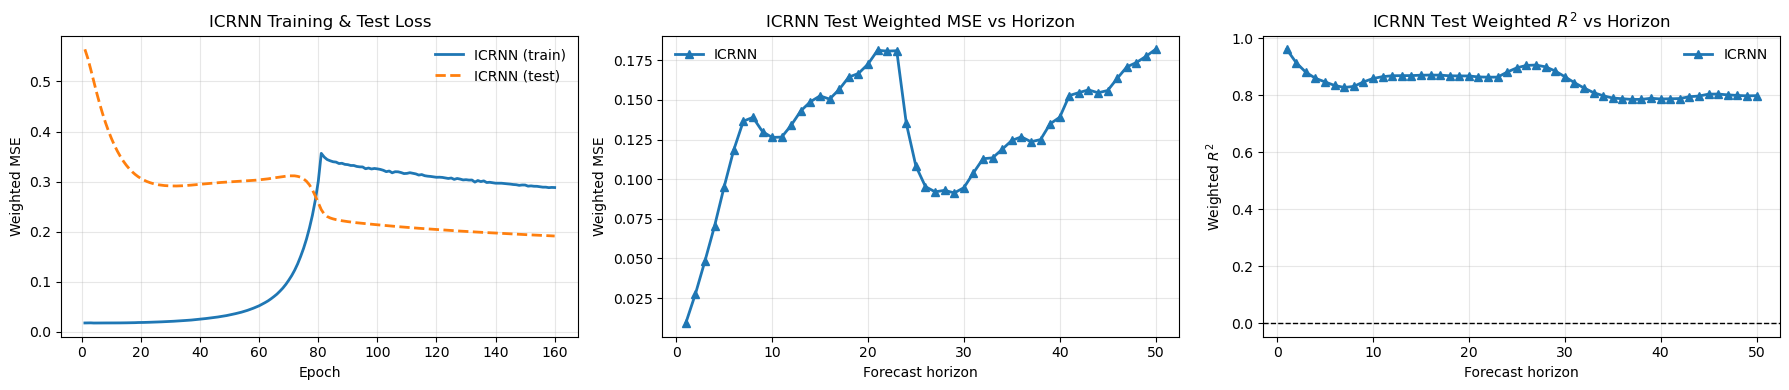


Per-trial post-stim weighted MSE (first 50 steps, test set, ICRNN):
  Trial 9: wMSE = 0.307906
  Trial 12: wMSE = 0.107625
  Trial 15: wMSE = 0.099830
  Trial 16: wMSE = 0.048370 <-- best
  Trial 18: wMSE = 0.945123
  Trial 19: wMSE = 0.496906
  Trial 24: wMSE = 0.248940
  Trial 29: wMSE = 0.565657
  Trial 30: wMSE = 0.638972
  Trial 31: wMSE = 0.249749
  Trial 51: wMSE = 1.592057
  Trial 55: wMSE = 0.069041
  Trial 56: wMSE = 0.173638
  Trial 60: wMSE = 0.112293
  Trial 66: wMSE = 0.507801
  Trial 75: wMSE = 0.560616
  Trial 78: wMSE = 0.135367
  Trial 84: wMSE = 0.139904
  Trial 94: wMSE = 0.223955
  Trial 97: wMSE = 0.615635
  Trial 98: wMSE = 0.379964
  Trial 100: wMSE = 0.212918
  Trial 101: wMSE = 0.185465
  Trial 104: wMSE = 0.414068
  Trial 105: wMSE = 0.395745
  Trial 109: wMSE = 0.241297
  Trial 131: wMSE = 0.259226
  Trial 133: wMSE = 0.247011
  Trial 138: wMSE = 0.558893
  Trial 143: wMSE = 1.334508
  Trial 144: wMSE = 1.676021
  Trial 153: wMSE = 0.569732
  Trial 158: wMS

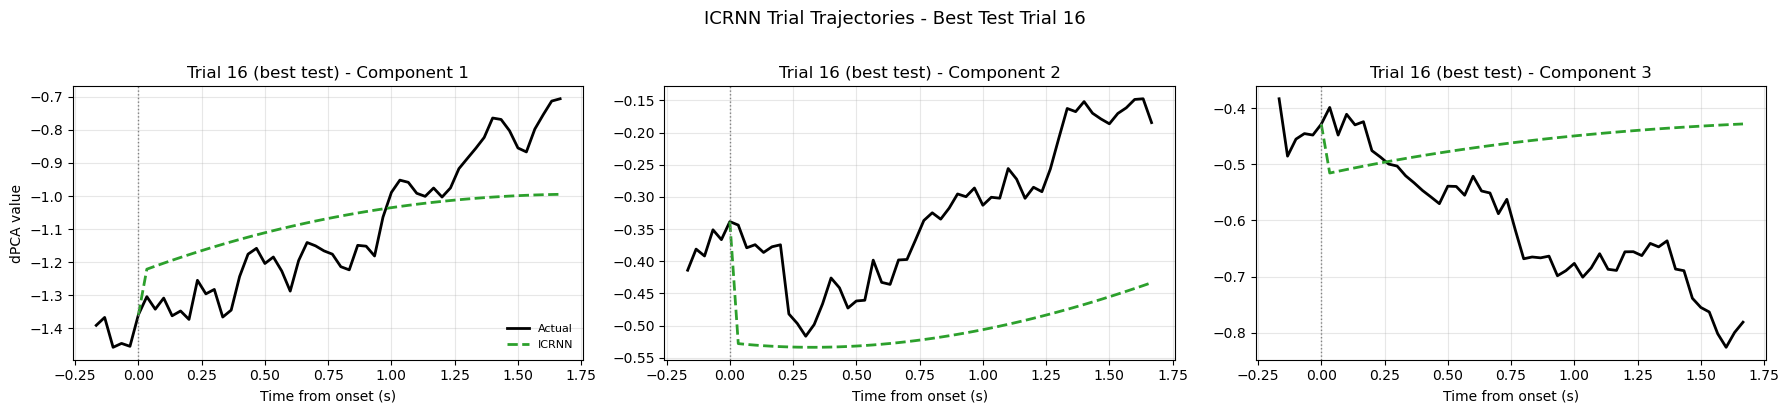

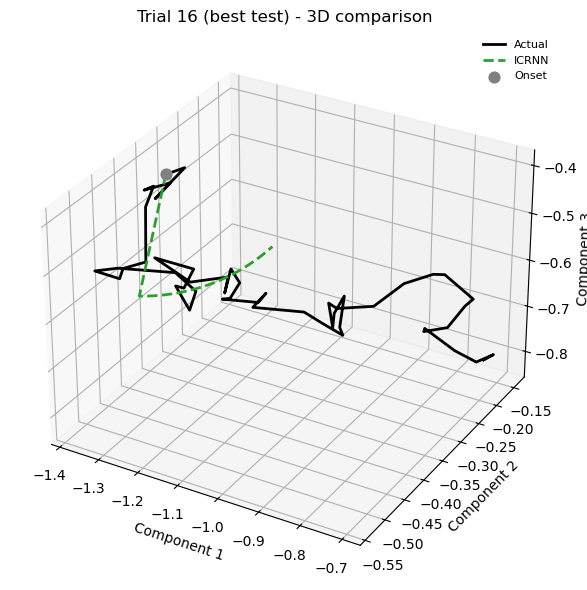

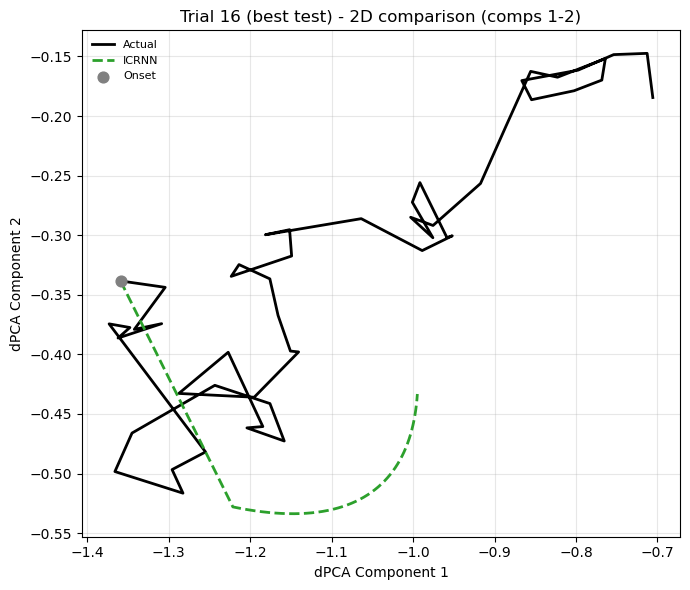

Training time (ICRNN): 481.78 s (3.0111 s/epoch)
Inference time (ICRNN): 0.022039 s

ICRNN weighted metrics (first 5 horizons):
   h    ICRNN MSE     ICRNN R²
t+01      0.00924      0.96143
t+02      0.02755      0.91386
t+03      0.04845      0.88077
t+04      0.07042      0.85957
t+05      0.09520      0.84685


In [14]:
# =============================================================================
# ICRNN (input-convex recurrent model) with post-dPCA augmentation (same as cell 10)
# =============================================================================

import copy
import torch.nn.functional as F

# Reuse the exact post-dPCA + EMA augmentation strategy from cell 10.
required_vars = [
    'aug_train_loader', 'aug_train_ds',
    'weighted_mse_loss', 'component_weights_t', 'component_weights',
    'horizon', 'horizons', 'd_z', 'n_cells', 'device'
]
missing = [name for name in required_vars if name not in globals()]
if missing:
    raise RuntimeError(
        "Missing required variables for ICRNN cell: " + ", ".join(missing)
    )

# Use augmented test split when available; otherwise fall back to this notebook's standard test split.
if 'test_loader_aug' in globals() and 'test_ds_aug' in globals():
    eval_loader, eval_ds = test_loader_aug, test_ds_aug
elif 'test_loader' in globals() and 'test_ds' in globals():
    eval_loader, eval_ds = test_loader, test_ds
else:
    raise RuntimeError("Missing test loader/dataset: need (test_loader_aug, test_ds_aug) or (test_loader, test_ds).")


class ICRNNCell(torch.nn.Module):
    """Stabilized convex recurrent update with a deeper convex residual.

    We use a signed affine backbone plus a bounded 2-layer input-convex residual
    with width hidden_dim=128 for both input projection and hidden state:
      h1 = softplus(Wz1 z_prev + Wv1 v_t + b1), h1 in R^128
      h2 = softplus(Wh h1 + b2), h2 in R^128
      r = softplus(Wout h2 + b3), r in R^{d_z}
      z_next = a * z_prev + (1-a) * [A_z z_prev + A_v v_t + b + eta * r]

    Convexity in state/input comes from nonnegative convex-path weights and
    monotone convex activations. Affine terms preserve convexity while allowing
    signed outputs.
    """

    def __init__(self, latent_dim, stim_dim, hidden_dim=128, rho=0.7):
        super().__init__()
        self.latent_dim = latent_dim
        self.stim_dim = stim_dim
        self.hidden_dim = int(hidden_dim)
        self.rho = float(rho)

        # 2-layer convex residual parameters (constrained nonnegative).
        self.raw_Wz1 = torch.nn.Parameter(0.01 * torch.randn(self.hidden_dim, latent_dim))
        self.raw_Wv1 = torch.nn.Parameter(0.01 * torch.randn(self.hidden_dim, stim_dim))
        self.raw_Wh = torch.nn.Parameter(0.01 * torch.randn(self.hidden_dim, self.hidden_dim))
        self.raw_Wout = torch.nn.Parameter(0.01 * torch.randn(latent_dim, self.hidden_dim))
        self.bias_conv1 = torch.nn.Parameter(torch.zeros(self.hidden_dim))
        self.bias_conv2 = torch.nn.Parameter(torch.zeros(self.hidden_dim))
        self.bias_conv3 = torch.nn.Parameter(torch.zeros(latent_dim))

        # Signed affine backbone.
        self.raw_Az = torch.nn.Parameter(0.01 * torch.randn(latent_dim, latent_dim))
        self.raw_Av = torch.nn.Parameter(0.01 * torch.randn(latent_dim, stim_dim))
        self.bias_aff = torch.nn.Parameter(torch.zeros(latent_dim))

        # Step size and convex residual strength.
        self.alpha_raw = torch.nn.Parameter(torch.full((latent_dim,), 1.2))
        self.eta_raw = torch.nn.Parameter(torch.full((latent_dim,), -2.0))

    def _constrained_Wz1(self):
        Wz_pos = F.softplus(self.raw_Wz1)
        row_sum = Wz_pos.sum(dim=1, keepdim=True).clamp_min(1e-6)
        return (Wz_pos / row_sum) * self.rho

    def _constrained_Wv1(self):
        return F.softplus(self.raw_Wv1)

    def _constrained_Wh(self):
        Wh_pos = F.softplus(self.raw_Wh)
        row_sum = Wh_pos.sum(dim=1, keepdim=True).clamp_min(1e-6)
        return (Wh_pos / row_sum) * self.rho

    def _constrained_Wout(self):
        Wout_pos = F.softplus(self.raw_Wout)
        row_sum = Wout_pos.sum(dim=1, keepdim=True).clamp_min(1e-6)
        return (Wout_pos / row_sum) * self.rho

    def _stable_Az(self):
        I = torch.eye(self.latent_dim, device=self.raw_Az.device, dtype=self.raw_Az.dtype)
        Az = I + 0.05 * torch.tanh(self.raw_Az)
        op_norm = torch.linalg.matrix_norm(Az, ord=2)
        max_norm = 0.98
        if op_norm > max_norm:
            Az = Az * (max_norm / op_norm)
        return Az

    def _stable_Av(self):
        return 0.05 * self.raw_Av

    def forward(self, z_prev, v_t):
        Wz1 = self._constrained_Wz1()
        Wv1 = self._constrained_Wv1()
        Wh = self._constrained_Wh()
        Wout = self._constrained_Wout()
        Az = self._stable_Az()
        Av = self._stable_Av()

        # Keep updates small for stiff dynamics.
        alpha = 0.92 + 0.07 * torch.sigmoid(self.alpha_raw)
        eta = 0.20 * torch.sigmoid(self.eta_raw)

        pre_conv1 = z_prev @ Wz1.T + v_t @ Wv1.T + self.bias_conv1
        h1 = F.softplus(pre_conv1)
        pre_conv2 = h1 @ Wh.T + self.bias_conv2
        h2 = F.softplus(pre_conv2)
        pre_conv3 = h2 @ Wout.T + self.bias_conv3
        convex_term = F.softplus(pre_conv3)

        affine_term = z_prev @ Az.T + v_t @ Av.T + self.bias_aff
        z_candidate = affine_term + eta[None, :] * convex_term

        z_next = alpha[None, :] * z_prev + (1.0 - alpha[None, :]) * z_candidate
        return z_next


class ICRNNStimForecast(torch.nn.Module):
    def __init__(self, latent_dim, stim_dim, hidden_dim=128, rho=0.7):
        super().__init__()
        self.cell = ICRNNCell(latent_dim=latent_dim, stim_dim=stim_dim, hidden_dim=hidden_dim, rho=rho)

    def forward(self, context_z, context_v, future_v, target_z=None, teacher_forcing=0.0):
        z_prev = context_z[:, -1, :]
        H = future_v.shape[1]
        preds = []

        for h in range(H):
            if h > 0 and target_z is not None and teacher_forcing > 0.0:
                z_prev = teacher_forcing * target_z[:, h - 1, :] + (1.0 - teacher_forcing) * z_prev
            z_prev = self.cell(z_prev, future_v[:, h, :])
            preds.append(z_prev)

        return torch.stack(preds, dim=1)


class ParameterEMA:
    """EMA shadow model for stabler evaluation in stiff dynamics."""

    def __init__(self, model, decay=0.99):
        self.decay = float(decay)
        self.shadow = copy.deepcopy(model).eval()
        for p in self.shadow.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model):
        msd = model.state_dict()
        ssd = self.shadow.state_dict()
        for k in ssd.keys():
            ssd[k].mul_(self.decay).add_(msd[k], alpha=1.0 - self.decay)


def temporal_smoothness_loss(pred, target):
    if pred.shape[1] < 2:
        return pred.new_tensor(0.0)
    dp = pred[:, 1:, :] - pred[:, :-1, :]
    dt = target[:, 1:, :] - target[:, :-1, :]
    return F.mse_loss(dp, dt)


def state_bound_loss(pred, bound=4.0):
    # Keep normalized latent predictions near the training manifold.
    overflow = F.relu(torch.abs(pred) - bound)
    return (overflow ** 2).mean()


# -----------------------------
# Train ICRNN on the same augmented dataset from cell 10
# -----------------------------
model_icrnn = ICRNNStimForecast(latent_dim=d_z, stim_dim=n_cells, hidden_dim=128, rho=0.7).to(device)
optimizer_icrnn = torch.optim.AdamW(model_icrnn.parameters(), lr=1e-4, weight_decay=3e-4)
ema_icrnn = ParameterEMA(model_icrnn, decay=0.99)

n_epochs_icrnn = 160
loss_history_icrnn = []
test_loss_history_icrnn = []

lambda_smooth = 0.05
lambda_bound = 0.01

train_t0_icrnn = time.perf_counter()
for epoch in range(1, n_epochs_icrnn + 1):
    model_icrnn.train()
    running_loss = 0.0

    #Not so much teacher forcing, since the model should learn to be stable on its own with the EMA augmentation. Linearly decay from 0.98 to 0.0 over the first 80 epochs.
    tf_ratio = max(0.0, 0.98 - (0.98 / 80) * (epoch - 1))

    for context_z_b, context_v_b, future_v_b, target_z_b in aug_train_loader:
        context_z_b = context_z_b.to(device)
        context_v_b = context_v_b.to(device)
        future_v_b = future_v_b.to(device)
        target_z_b = target_z_b.to(device)

        optimizer_icrnn.zero_grad(set_to_none=True)
        pred_z_b = model_icrnn(
            context_z_b, context_v_b, future_v_b,
            target_z=target_z_b, teacher_forcing=tf_ratio
        )

        loss_recon = weighted_mse_loss(pred_z_b, target_z_b, component_weights_t)
        loss_smooth = temporal_smoothness_loss(pred_z_b, target_z_b)
        loss_bound = state_bound_loss(pred_z_b, bound=4.0)
        loss = loss_recon + lambda_smooth * loss_smooth + lambda_bound * loss_bound

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_icrnn.parameters(), 0.3)
        optimizer_icrnn.step()
        ema_icrnn.update(model_icrnn)

        running_loss += loss.item() * context_z_b.shape[0]

    epoch_loss = running_loss / len(aug_train_ds)
    loss_history_icrnn.append(epoch_loss)

    # Evaluate EMA model (open loop)
    ema_icrnn.shadow.eval()
    with torch.no_grad():
        test_running = 0.0
        for context_z_b, context_v_b, future_v_b, target_z_b in eval_loader:
            context_z_b = context_z_b.to(device)
            context_v_b = context_v_b.to(device)
            future_v_b = future_v_b.to(device)
            target_z_b = target_z_b.to(device)
            pred_z_b = ema_icrnn.shadow(context_z_b, context_v_b, future_v_b, target_z=None, teacher_forcing=0.0)
            test_running += weighted_mse_loss(pred_z_b, target_z_b, component_weights_t).item() * context_z_b.shape[0]
        test_loss_history_icrnn.append(test_running / len(eval_ds))

    if epoch % 20 == 0 or epoch == 1:
        print(
            f"[ICRNN] Epoch {epoch:03d}/{n_epochs_icrnn} | "
            f"loss={epoch_loss:.6f} | test_loss={test_loss_history_icrnn[-1]:.6f} | tf={tf_ratio:.3f}"
        )

training_time_icrnn = time.perf_counter() - train_t0_icrnn


# -----------------------------
# Evaluate on clean test set (same protocol)
# -----------------------------
ema_icrnn.shadow.eval()
with torch.no_grad():
    (ctx_z_t, ctx_v_t, fut_v_t, tgt_z_t) = next(iter(eval_loader))
    ctx_z_t = ctx_z_t.to(device)
    ctx_v_t = ctx_v_t.to(device)
    fut_v_t = fut_v_t.to(device)

    if device.type == 'cuda':
        torch.cuda.synchronize()
    infer_t0_icrnn = time.perf_counter()
    pred_z_t_icrnn = ema_icrnn.shadow(ctx_z_t, ctx_v_t, fut_v_t, target_z=None, teacher_forcing=0.0)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    inference_time_icrnn = time.perf_counter() - infer_t0_icrnn

pred_z_t_icrnn = pred_z_t_icrnn.cpu().numpy()
tgt_z_t = tgt_z_t.numpy()

pred_z_icrnn = pred_z_t_icrnn * z_std + z_mean
target_z_icrnn = tgt_z_t * z_std + z_mean

weighted_mse_by_h_icrnn = []
weighted_r2_by_h_icrnn = []

for h in range(horizon):
    y_true_h = target_z_icrnn[:, h, :]
    y_pred_h = pred_z_icrnn[:, h, :]

    mse_per_comp = np.mean((y_pred_h - y_true_h) ** 2, axis=0)
    weighted_mse = float(np.sum(component_weights * mse_per_comp))

    r2_per_comp = np.zeros(d_z, dtype=np.float64)
    for comp in range(d_z):
        if np.var(y_true_h[:, comp]) < 1e-12:
            r2_per_comp[comp] = 0.0
        else:
            r2_per_comp[comp] = r2_score(y_true_h[:, comp], y_pred_h[:, comp])
    weighted_r2 = float(np.sum(component_weights * r2_per_comp))

    weighted_mse_by_h_icrnn.append(weighted_mse)
    weighted_r2_by_h_icrnn.append(weighted_r2)


# -----------------------------
# ICRNN-only evaluation graphs
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Training curves
axes[0].plot(np.arange(1, n_epochs_icrnn + 1), loss_history_icrnn, lw=2, label='ICRNN (train)')
axes[0].plot(np.arange(1, n_epochs_icrnn + 1), test_loss_history_icrnn, lw=2, ls='--', label='ICRNN (test)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Weighted MSE')
axes[0].set_title('ICRNN Training & Test Loss')
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.3)

# Weighted MSE vs horizon
axes[1].plot(horizons, weighted_mse_by_h_icrnn, marker='^', lw=2, label='ICRNN')
axes[1].set_xlabel('Forecast horizon')
axes[1].set_ylabel('Weighted MSE')
axes[1].set_title('ICRNN Test Weighted MSE vs Horizon')
axes[1].legend(frameon=False)
axes[1].grid(alpha=0.3)

# Weighted R^2 vs horizon
axes[2].plot(horizons, weighted_r2_by_h_icrnn, marker='^', lw=2, label='ICRNN')
axes[2].axhline(0.0, color='k', ls='--', lw=1)
axes[2].set_xlabel('Forecast horizon')
axes[2].set_ylabel('Weighted $R^2$')
axes[2].set_title('ICRNN Test Weighted $R^2$ vs Horizon')
axes[2].legend(frameon=False)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# -----------------------------
# ICRNN trajectory graphs (best test trial)
# -----------------------------
wmse_selection_steps = min(50, horizon)
per_trial_wmse_icrnn = np.zeros(len(test_indices), dtype=np.float64)

ema_icrnn.shadow.eval()
with torch.no_grad():
    for i, tr in enumerate(test_indices):
        context_z_single = torch.from_numpy(z_trial_n[tr, :context_len, :]).unsqueeze(0).to(device)
        context_v_single = torch.from_numpy(v[tr, :context_len, :]).unsqueeze(0).to(device)
        future_v_single = torch.from_numpy(v[tr, zero_idx + 1:zero_idx + 1 + horizon, :]).unsqueeze(0).to(device)

        pred_icrnn_n = ema_icrnn.shadow(context_z_single, context_v_single, future_v_single, target_z=None, teacher_forcing=0.0)
        pred_icrnn_single_i = pred_icrnn_n.squeeze(0).cpu().numpy() * z_std.squeeze((0, 1)) + z_mean.squeeze((0, 1))

        true_post_i = z_trial[tr, zero_idx + 1:zero_idx + 1 + horizon, :]
        # Select trajectory by early post-stim accuracy only (first 50 steps).
        diff_i = pred_icrnn_single_i[:wmse_selection_steps] - true_post_i[:wmse_selection_steps]
        mse_per_comp_i = np.mean(diff_i ** 2, axis=0)
        per_trial_wmse_icrnn[i] = float(np.sum(component_weights * mse_per_comp_i))

best_test_idx_icrnn = int(np.argmin(per_trial_wmse_icrnn))
trial_id = int(test_indices[best_test_idx_icrnn])

print(f"\nPer-trial post-stim weighted MSE (first {wmse_selection_steps} steps, test set, ICRNN):")
for i, tr in enumerate(test_indices):
    marker = ' <-- best' if i == best_test_idx_icrnn else ''
    print(f'  Trial {int(tr)}: wMSE = {per_trial_wmse_icrnn[i]:.6f}{marker}')
print(f"\nUsing test trial {trial_id} (lowest post-stim wMSE over first {wmse_selection_steps} steps = {per_trial_wmse_icrnn[best_test_idx_icrnn]:.6f}) for trajectory plots.")

pre_steps = 5

context_z_single = torch.from_numpy(z_trial_n[trial_id, :context_len, :]).unsqueeze(0).to(device)
context_v_single = torch.from_numpy(v[trial_id, :context_len, :]).unsqueeze(0).to(device)
future_v_single = torch.from_numpy(v[trial_id, zero_idx + 1:zero_idx + 1 + horizon, :]).unsqueeze(0).to(device)

with torch.no_grad():
    pred_icrnn_n = ema_icrnn.shadow(context_z_single, context_v_single, future_v_single, target_z=None, teacher_forcing=0.0)

pred_icrnn_single = pred_icrnn_n.squeeze(0).cpu().numpy() * z_std.squeeze((0, 1)) + z_mean.squeeze((0, 1))

start_idx = zero_idx - pre_steps
end_idx = zero_idx + 1 + horizon
t_window = time_axis[start_idx:end_idx]
true_window = z_trial[trial_id, start_idx:end_idx, :]

pred_win_icrnn = np.full((pre_steps + 1 + horizon, d_z), np.nan, dtype=np.float32)
pred_win_icrnn[pre_steps, :] = true_window[pre_steps, :]
pred_win_icrnn[pre_steps + 1:, :] = pred_icrnn_single

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=True)
for comp in range(3):
    axes[comp].plot(t_window, true_window[:, comp], lw=2, label='Actual', color='black')
    axes[comp].plot(t_window, pred_win_icrnn[:, comp], lw=2, ls='--', label='ICRNN', color='tab:green')
    axes[comp].axvline(0.0, color='gray', ls=':', lw=1)
    axes[comp].set_title(f'Trial {trial_id} (best test) - Component {comp + 1}')
    axes[comp].set_xlabel('Time from onset (s)')
    axes[comp].grid(alpha=0.3)

axes[0].set_ylabel('dPCA value')
axes[0].legend(frameon=False, fontsize=8)
plt.suptitle(f'ICRNN Trial Trajectories - Best Test Trial {trial_id}', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

# 3D comparison
onset_state = z_trial[trial_id, zero_idx, :]
true_post = z_trial[trial_id, zero_idx + 1:zero_idx + 1 + horizon, :]
true_from_onset = np.vstack([onset_state[None, :], true_post])
icrnn_from_onset = np.vstack([onset_state[None, :], pred_icrnn_single])

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot(true_from_onset[:, 0], true_from_onset[:, 1], true_from_onset[:, 2], color='black', lw=2, label='Actual')
ax.plot(icrnn_from_onset[:, 0], icrnn_from_onset[:, 1], icrnn_from_onset[:, 2], color='tab:green', lw=2, ls='--', label='ICRNN')
ax.scatter(onset_state[0], onset_state[1], onset_state[2], color='gray', s=60, zorder=5, label='Onset')
ax.set_title(f'Trial {trial_id} (best test) - 3D comparison')
ax.set_xlabel('Component 1')
ax.set_ylabel('Component 2')
ax.set_zlabel('Component 3')
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

# 2D trajectory (components 1 & 2)
fig, ax2d = plt.subplots(figsize=(7, 6))
ax2d.plot(true_from_onset[:, 0], true_from_onset[:, 1], color='black', lw=2, label='Actual')
ax2d.plot(icrnn_from_onset[:, 0], icrnn_from_onset[:, 1], color='tab:green', lw=2, ls='--', label='ICRNN')
ax2d.scatter(onset_state[0], onset_state[1], color='gray', s=60, zorder=5, label='Onset')
ax2d.set_title(f'Trial {trial_id} (best test) - 2D comparison (comps 1-2)')
ax2d.set_xlabel('dPCA Component 1')
ax2d.set_ylabel('dPCA Component 2')
ax2d.legend(frameon=False, fontsize=8)
ax2d.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Training time (ICRNN): {training_time_icrnn:.2f} s ({training_time_icrnn / n_epochs_icrnn:.4f} s/epoch)")
print(f"Inference time (ICRNN): {inference_time_icrnn:.6f} s")
print("\nICRNN weighted metrics (first 5 horizons):")
print(f"{'h':>4s}  {'ICRNN MSE':>11s}  {'ICRNN R²':>11s}")
for h in range(min(5, horizon)):
    print(
        f"t+{h+1:02d}  "
        f"{weighted_mse_by_h_icrnn[h]:11.5f}  "
        f"{weighted_r2_by_h_icrnn[h]:11.5f}"
    )

## Linear Dynamical System (LDS) via Ridge Regression — Baseline Comparison

### Motivation

Before comparing increasingly sophisticated neural-network forecasters, it is essential to establish a **linear baseline**. A Linear Dynamical System (LDS) fit by Ridge regression provides exactly this: it captures the best purely-linear one-step dynamics $z_{t+1} = Az_t + Bv_t$ and then rolls them forward autoregressively over the same forecast horizon used by the LSTM and PICNN-RNN.

If the nonlinear models offer only marginal improvement over the LDS, the latent dynamics are well-approximated by a linear map and the additional complexity is unwarranted. Conversely, a large gap validates the need for expressive architectures (and, in the PICNN-RNN case, partial convexity for future MPC optimisation).

### System Dynamics

$$z_{t+1} = Az_t + Bv_t + \epsilon_t$$

where:
- $z_t \in \mathbb{R}^{d_z}$ — latent state (dPCA components, EMA-smoothed, normalised)
- $v_t \in \mathbb{R}^{n_{\text{cells}}}$ — photostimulation vector
- $A \in \mathbb{R}^{d_z \times d_z}$ — state-transition matrix (autonomous dynamics)
- $B \in \mathbb{R}^{d_z \times n_{\text{cells}}}$ — input matrix (stimulation influence)

### Ridge Regression Objective

$$\min_{A,\,B}\;\sum_t \|z_{t+1} - (Az_t + Bv_t)\|_2^2 \;+\; \lambda\bigl(\|A\|_F^2 + \|B\|_F^2\bigr)$$

Closed-form solution (no iterative training):

$$W = (X^\top X + \lambda I)^{-1}\,X^\top Y$$

### Data Pipeline (identical to RNN cells)

| Aspect | Detail |
|---|---|
| Latent space | Same dPCA projection + EMA smoothing |
| Normalisation | Same z-score from training split |
| Stimulation vectors | Full photostimulation vectors $v_t$ per trial |
| Augmentation | Same peri-onset Gaussian noise (K=20 noisy copies of stimulated trials) |
| Train / test split | Same 80/20 random split |
| Forecast setup | Same context (up to onset) → predict $H=20$ post-onset steps |

### Multi-Step Prediction

$$\hat{z}_{t+1} = A\hat{z}_t + Bv_t, \quad t = 0, \ldots, H-1$$

starting from the onset state $\hat{z}_0 = z_{\text{onset}}$.

### Key Advantage

The LDS is fit in **closed form** — no epochs, no backpropagation, no GPU needed. This makes it orders of magnitude faster to train and provides an interpretable linear reference against which the PICNN-RNN's nonlinear + convex architecture can be judged.

Using TOP-3 dPCA components (stimulus, time, interaction)
Latent dim: 3, horizon: 20
LDS training pairs: 741,211 (from 129 trials, augmented stimulated x21)
LDS fit in 1.7269 s | A: (3, 3), B: (3, 471) | rho(A)=0.9982 (stable)
LDS inference (33 trials, H=20): 0.001735 s

PICRNN (Top-3 dPCA) params: 426,510
Training on top-3 dPCA augmented data (1769 samples)
Epoch 001/200 | train=12.776855 | test=0.597478 | lr=1.0e-03 | tf=0.700 | no_improve=0
Epoch 020/200 | train=0.044782 | test=0.252343 | lr=1.0e-03 | tf=0.643 | no_improve=3
Epoch 040/200 | train=0.042424 | test=0.163253 | lr=1.0e-03 | tf=0.582 | no_improve=6
Epoch 060/200 | train=0.037592 | test=0.139290 | lr=5.0e-04 | tf=0.522 | no_improve=10
Epoch 080/200 | train=0.035443 | test=0.103733 | lr=2.5e-04 | tf=0.462 | no_improve=5
Epoch 100/200 | train=0.034433 | test=0.118451 | lr=6.3e-05 | tf=0.402 | no_improve=11
Epoch 120/200 | train=0.034230 | test=0.078744 | lr=3.1e-05 | tf=0.341 | no_improve=16
Epoch 140/200 | train=0.036770 | 

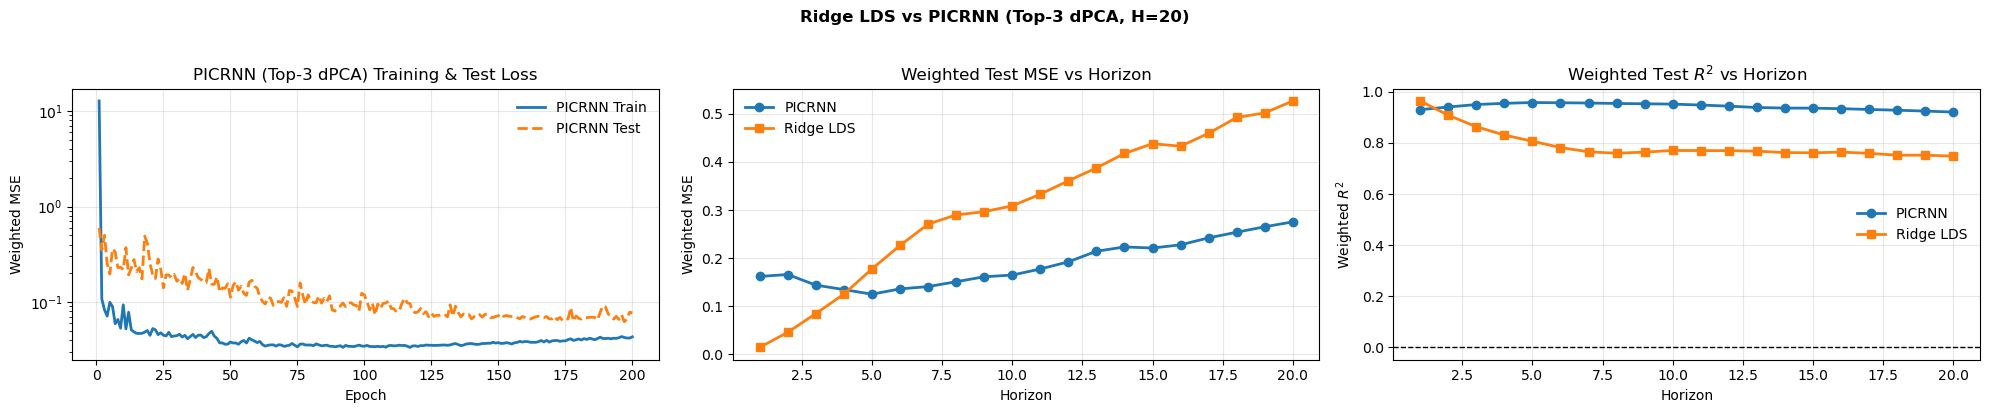


Per-trial post-stim weighted MSE (test set, PICRNN Top-3 dPCA):
  Trial 9: wMSE = 0.136422
  Trial 12: wMSE = 0.056673
  Trial 15: wMSE = 0.019386
  Trial 16: wMSE = 0.016920
  Trial 18: wMSE = 0.205310
  Trial 19: wMSE = 0.134703
  Trial 24: wMSE = 0.043733
  Trial 29: wMSE = 0.465688
  Trial 30: wMSE = 0.077326
  Trial 31: wMSE = 0.073672
  Trial 51: wMSE = 0.020976
  Trial 55: wMSE = 0.017860
  Trial 56: wMSE = 0.714837
  Trial 60: wMSE = 0.053538
  Trial 66: wMSE = 0.350153
  Trial 75: wMSE = 0.152927
  Trial 78: wMSE = 0.014175
  Trial 84: wMSE = 0.776342
  Trial 94: wMSE = 0.061322
  Trial 97: wMSE = 0.044649
  Trial 98: wMSE = 0.020160
  Trial 100: wMSE = 0.094074
  Trial 101: wMSE = 0.181488
  Trial 104: wMSE = 0.222518
  Trial 105: wMSE = 0.011993 <-- best
  Trial 109: wMSE = 0.062426
  Trial 131: wMSE = 0.052341
  Trial 133: wMSE = 0.020191
  Trial 138: wMSE = 0.076876
  Trial 143: wMSE = 1.547608
  Trial 144: wMSE = 0.307547
  Trial 153: wMSE = 0.063534
  Trial 158: wMSE = 

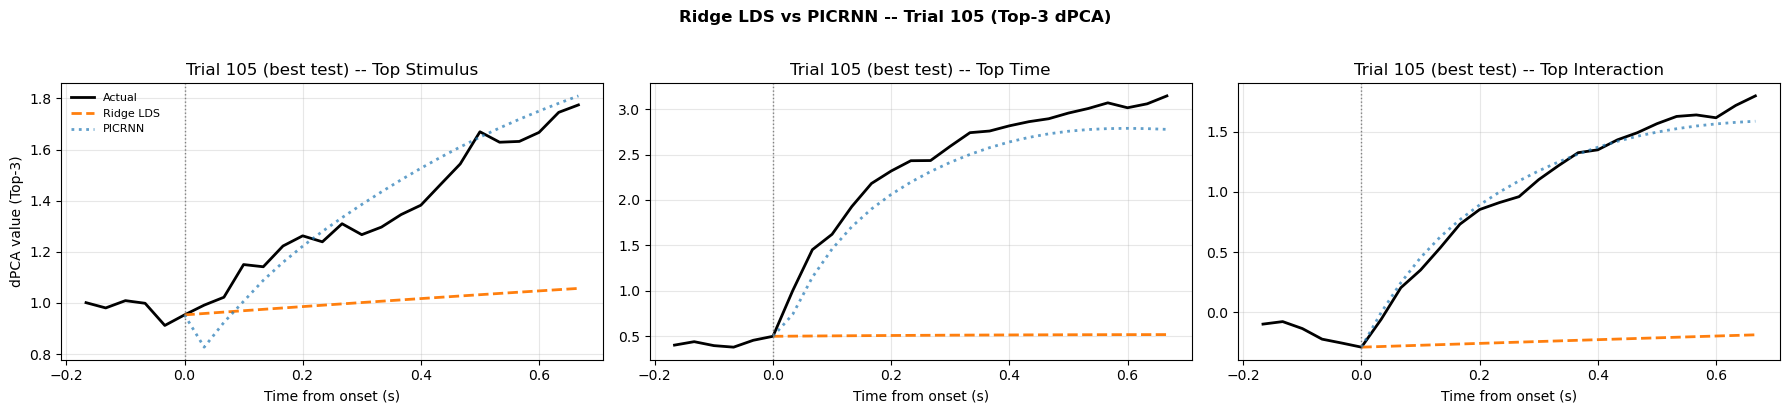

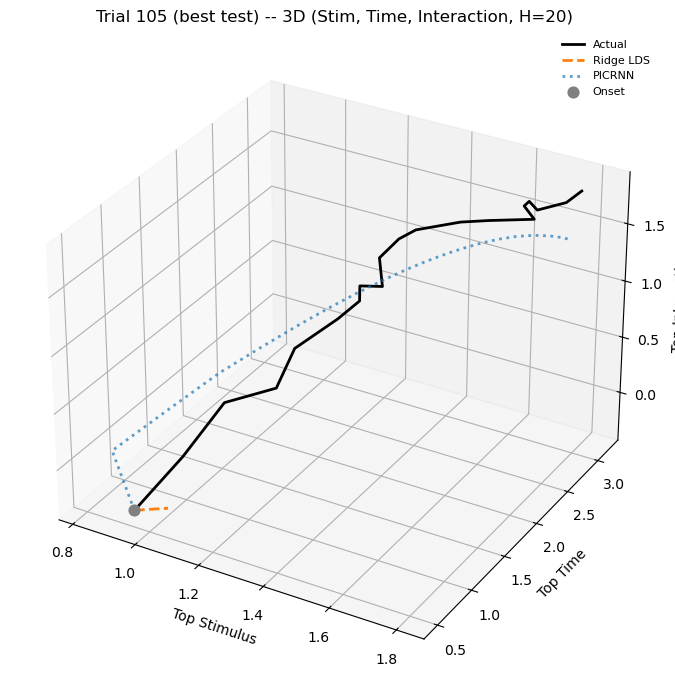

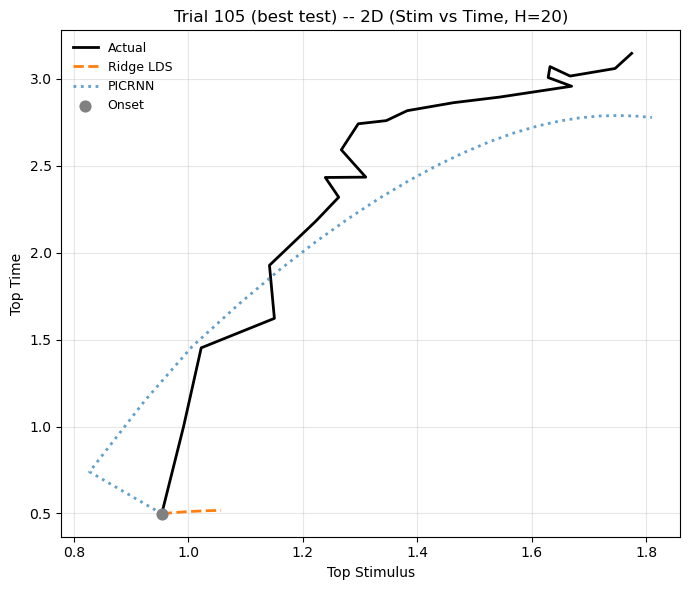

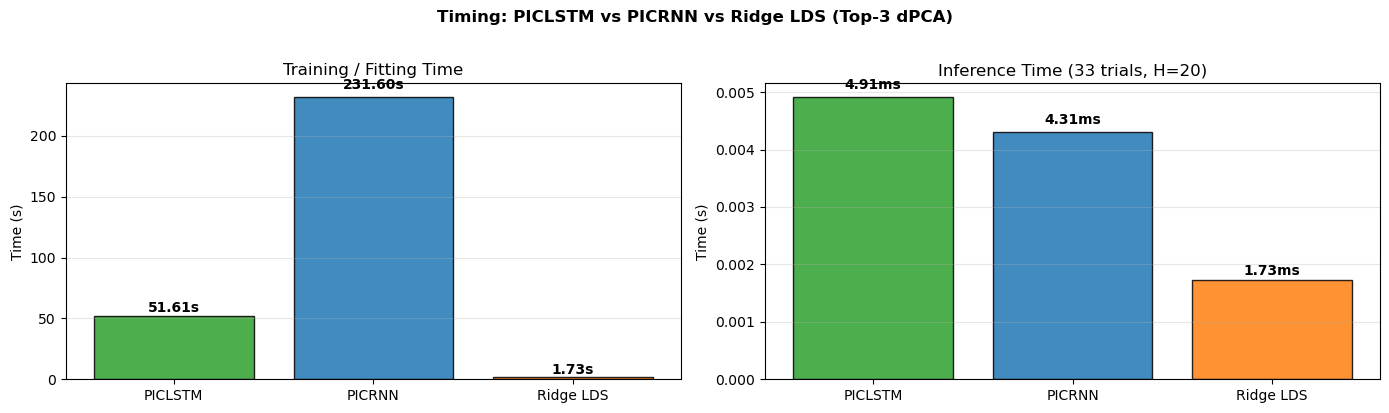


RIDGE LDS vs PICRNN SUMMARY (Top-3 dPCA: stimulus, time, interaction)
Ridge LDS: z_{t+1} = A z_t + B v_t  (alpha=1.0)
  A: (3, 3), B: (3, 471), rho(A)=0.9982
  Fit time: 1.7269s | Inference: 0.001735s

PICRNN (softplus(-3.0) init, 3 convex layers):
  Params: 426,510
  Train time: 231.60s (200 epochs)
  Inference: 0.004309s

COMPARISON (average over H=20)
Metric                       Ridge LDS       PICRNN        Delta
-------------------------------------------------------------
Weighted MSE                   0.30941      0.18879     +0.12063
Weighted R2                    0.79090      0.94215     -0.15126
Train/Fit time (s)              1.7269     231.6048    -229.8779
Inference time (ms)             1.7350       4.3090      -2.5740
Spectral radius(A)              0.9982          N/A             


In [ ]:
# =============================================================================
# Ridge LDS vs PICRNN — Both on TOP-3 dPCA components
# =============================================================================
# Uses z_trial_n_top3 / z_trial_top3 (top stimulus, top time, top interaction)
# from the PICRNN Top-3 cell.
# Trains a fresh PICRNN (with softplus(-3.0) init) on the same data.
# Ridge LDS rollout uses the SAME horizon as PICRNN.

import copy as copy_ridge
from sklearn.linear_model import Ridge

print(f"Using TOP-3 dPCA components (stimulus, time, interaction)")
print(f"Latent dim: {d_z_top3}, horizon: {horizon}")

# =============================================================================
# 1) RidgeLDS class
# =============================================================================

class RidgeLDS:
    """Linear Dynamical System: z_{t+1} = A @ z_t + B @ v_t, fit via Ridge."""
    def __init__(self, alpha: float = 1.0):
        self.alpha = alpha
        self.A = self.B = None
        self.n_latent = self.n_inputs = None

    def fit(self, Z_prev, V, Z_next):
        self.n_latent = Z_prev.shape[1]
        self.n_inputs = V.shape[1]
        X = np.hstack([Z_prev, V])
        model = Ridge(alpha=self.alpha, fit_intercept=False)
        model.fit(X, Z_next)
        W = model.coef_
        self.A = W[:, :self.n_latent]
        self.B = W[:, self.n_latent:]
        return self

    def predict_trajectory(self, z0, V_seq):
        H = V_seq.shape[0]
        Z_pred = np.zeros((H, self.n_latent))
        z = z0.copy()
        for t in range(H):
            z = self.A @ z + self.B @ V_seq[t]
            Z_pred[t] = z
        return Z_pred

    def spectral_radius(self):
        return float(np.max(np.abs(np.linalg.eigvals(self.A))))

# =============================================================================
# 2) Build augmented training pairs from top-3 dPCA data
# =============================================================================

rng_lds = np.random.default_rng(42)
Z_prev_list, V_list, Z_next_list = [], [], []

for i, tr in enumerate(train_indices):
    is_stim = train_stim_mask[i]
    n_copies = 1 + (n_augment if is_stim else 0)
    for copy_k in range(n_copies):
        z_seq = z_trial_n_top3[tr].copy()  # top-3 dPCA
        v_seq = v[tr].copy()
        if copy_k > 0:
            n_aug_steps = aug_end - aug_start
            z_seq[aug_start:aug_end, :] += (
                rng_lds.standard_normal((n_aug_steps, d_z_top3)).astype(np.float32) * noise_std_top3
            )
        Z_prev_list.append(z_seq[:-1])
        V_list.append(v_seq[:-1])
        Z_next_list.append(z_seq[1:])

Z_prev_all = np.vstack(Z_prev_list).astype(np.float64)
V_all = np.vstack(V_list).astype(np.float64)
Z_next_all = np.vstack(Z_next_list).astype(np.float64)

print(f"LDS training pairs: {Z_prev_all.shape[0]:,} (from {len(train_indices)} trials, "
      f"augmented stimulated x{1 + n_augment})")

# =============================================================================
# 3) Fit Ridge LDS
# =============================================================================

fit_t0 = time.perf_counter()
lds = RidgeLDS(alpha=1.0)
lds.fit(Z_prev_all, V_all, Z_next_all)
fit_time_lds = time.perf_counter() - fit_t0

rho = lds.spectral_radius()
print(f"LDS fit in {fit_time_lds:.4f} s | A: {lds.A.shape}, B: {lds.B.shape} | rho(A)={rho:.4f} "
      f"{'(stable)' if rho < 1 else '(unstable!)'}")

# =============================================================================
# 4) Ridge LDS multi-step forecast (same horizon as PICRNN)
# =============================================================================

infer_t0_lds = time.perf_counter()
pred_z_lds_n = np.zeros((len(test_indices), horizon, d_z_top3), dtype=np.float64)
for i, tr in enumerate(test_indices):
    z0 = z_trial_n_top3[tr, zero_idx, :]
    v_future = v[tr, zero_idx + 1:zero_idx + 1 + horizon, :]
    pred_z_lds_n[i] = lds.predict_trajectory(z0, v_future)
inference_time_lds = time.perf_counter() - infer_t0_lds

pred_z_lds = pred_z_lds_n * z_std_top3 + z_mean_top3
target_z_lds = z_trial_n_top3[test_indices, zero_idx + 1:zero_idx + 1 + horizon, :] * z_std_top3 + z_mean_top3

print(f"LDS inference ({len(test_indices)} trials, H={horizon}): {inference_time_lds:.6f} s")

# =============================================================================
# 5) Train a fresh PICRNN on top-3 dPCA data (same init strategy as before)
# =============================================================================
# PICRNNStimForecast class from cell 8 uses softplus(-3.0) init for non-neg weights.
# We reuse aug_train_loader_top3 / test_loader_top3 from the PICRNN Top-3 cell.

model_picrnn_015 = PICRNNStimForecast(
    latent_dim=d_z_top3, stim_dim=n_cells,
    hidden_dim=128, num_layers=2,
    n_convex_layers=3, convex_hidden=128,
    dropout=0.3,
).to(device)

n_params_picrnn_015 = sum(p.numel() for p in model_picrnn_015.parameters() if p.requires_grad)
print(f"\nPICRNN (Top-3 dPCA) params: {n_params_picrnn_015:,}")
print(f"Training on top-3 dPCA augmented data ({len(aug_train_ds_top3)} samples)")
print("=" * 60)

optimizer_picrnn_015 = torch.optim.AdamW(model_picrnn_015.parameters(), lr=1e-3, weight_decay=5e-4)
scheduler_picrnn_015 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_picrnn_015, mode='min', factor=0.5, patience=10, min_lr=1e-5
)

n_epochs_picrnn_015 = 200
early_stop_patience_picrnn_015 = 25
loss_hist_picrnn_015 = []
test_loss_hist_picrnn_015 = []

best_test_loss_picrnn_015 = float('inf')
best_state_picrnn_015 = None
no_improve_picrnn_015 = 0

train_t0_picrnn_015 = time.perf_counter()
for epoch in range(1, n_epochs_picrnn_015 + 1):
    model_picrnn_015.train()
    running_015 = 0.0
    tf_015 = 0.7 + (0.1 - 0.7) * ((epoch - 1) / max(n_epochs_picrnn_015 - 1, 1))

    for cz, cv, fv, tz in aug_train_loader_top3:
        cz, cv, fv, tz = cz.to(device), cv.to(device), fv.to(device), tz.to(device)
        optimizer_picrnn_015.zero_grad()
        pz = model_picrnn_015(cz, cv, fv, target_z=tz, teacher_forcing=tf_015)
        loss = weighted_mse_loss(pz, tz, comp_weights_top3_t)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_picrnn_015.parameters(), 1.0)
        optimizer_picrnn_015.step()
        running_015 += loss.item() * cz.shape[0]

    epoch_loss_015 = running_015 / len(aug_train_ds_top3)
    loss_hist_picrnn_015.append(epoch_loss_015)

    model_picrnn_015.eval()
    with torch.no_grad():
        test_run_015 = 0.0
        for cz, cv, fv, tz in test_loader_top3:
            cz, cv, fv, tz = cz.to(device), cv.to(device), fv.to(device), tz.to(device)
            pz = model_picrnn_015(cz, cv, fv, target_z=None, teacher_forcing=0.0)
            test_run_015 += weighted_mse_loss(pz, tz, comp_weights_top3_t).item() * cz.shape[0]
        cur_test_015 = test_run_015 / len(test_ds_top3)
        test_loss_hist_picrnn_015.append(cur_test_015)

    scheduler_picrnn_015.step(cur_test_015)

    if cur_test_015 < best_test_loss_picrnn_015:
        best_test_loss_picrnn_015 = cur_test_015
        best_state_picrnn_015 = copy_ridge.deepcopy(model_picrnn_015.state_dict())
        no_improve_picrnn_015 = 0
    else:
        no_improve_picrnn_015 += 1

    if epoch % 20 == 0 or epoch == 1:
        lr_now = optimizer_picrnn_015.param_groups[0]['lr']
        print(f"Epoch {epoch:03d}/{n_epochs_picrnn_015} | train={epoch_loss_015:.6f} | "
              f"test={cur_test_015:.6f} | lr={lr_now:.1e} | tf={tf_015:.3f} | "
              f"no_improve={no_improve_picrnn_015}")

    if no_improve_picrnn_015 >= early_stop_patience_picrnn_015:
        print(f"\nEarly stopping at epoch {epoch} (no improvement for "
              f"{early_stop_patience_picrnn_015} epochs). Best test loss: {best_test_loss_picrnn_015:.6f}")
        break

training_time_picrnn_015 = time.perf_counter() - train_t0_picrnn_015
actual_epochs_picrnn_015 = epoch

if best_state_picrnn_015 is not None:
    model_picrnn_015.load_state_dict(best_state_picrnn_015)
    print(f"Restored best model (test loss = {best_test_loss_picrnn_015:.6f})")

# =============================================================================
# 6) PICRNN inference on test set
# =============================================================================

model_picrnn_015.eval()
with torch.no_grad():
    cz_e, cv_e, fv_e, tz_e = next(iter(test_loader_top3))
    cz_e, cv_e, fv_e = cz_e.to(device), cv_e.to(device), fv_e.to(device)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    t0_inf_015 = time.perf_counter()
    pz_e_015 = model_picrnn_015(cz_e, cv_e, fv_e, target_z=None, teacher_forcing=0.0)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    inf_time_picrnn_015 = time.perf_counter() - t0_inf_015

pz_e_np_015 = pz_e_015.cpu().numpy() * z_std_top3 + z_mean_top3
tz_e_np_015 = tz_e.numpy() * z_std_top3 + z_mean_top3

# =============================================================================
# 7) Horizon-wise metrics for both models
# =============================================================================

weighted_mse_by_h_lds = []
weighted_r2_by_h_lds = []
weighted_mse_by_h_picrnn015 = []
weighted_r2_by_h_picrnn015 = []

for h in range(horizon):
    # Ridge LDS
    yt_lds = target_z_lds[:, h, :]
    yp_lds = pred_z_lds[:, h, :]
    mse_c = np.mean((yp_lds - yt_lds) ** 2, axis=0)
    w_mse = float(np.sum(comp_weights_top3 * mse_c))
    r2_c = np.zeros(d_z_top3)
    for c in range(d_z_top3):
        r2_c[c] = r2_score(yt_lds[:, c], yp_lds[:, c]) if np.var(yt_lds[:, c]) > 1e-12 else 0.0
    w_r2 = float(np.sum(comp_weights_top3 * r2_c))
    weighted_mse_by_h_lds.append(w_mse)
    weighted_r2_by_h_lds.append(w_r2)

    # PICRNN top-3
    yt_p = tz_e_np_015[:, h, :]
    yp_p = pz_e_np_015[:, h, :]
    mse_c = np.mean((yp_p - yt_p) ** 2, axis=0)
    w_mse = float(np.sum(comp_weights_top3 * mse_c))
    r2_c = np.zeros(d_z_top3)
    for c in range(d_z_top3):
        r2_c[c] = r2_score(yt_p[:, c], yp_p[:, c]) if np.var(yt_p[:, c]) > 1e-12 else 0.0
    w_r2 = float(np.sum(comp_weights_top3 * r2_c))
    weighted_mse_by_h_picrnn015.append(w_mse)
    weighted_r2_by_h_picrnn015.append(w_r2)

# =============================================================================
# 8) Comparison plots
# =============================================================================

print(f"\nTest trial indices ({len(test_indices)}): "
      f"{sorted(test_indices.tolist() if hasattr(test_indices, 'tolist') else list(test_indices))}")

fig, axes = plt.subplots(1, 3, figsize=(20, 4))

# Training/test loss (PICRNN only -- Ridge has no epochs)
axes[0].plot(np.arange(1, actual_epochs_picrnn_015 + 1), loss_hist_picrnn_015, lw=2, label='PICRNN Train')
axes[0].plot(np.arange(1, actual_epochs_picrnn_015 + 1), test_loss_hist_picrnn_015, lw=2, ls='--', label='PICRNN Test')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Weighted MSE')
axes[0].set_yscale('log')
axes[0].set_title('PICRNN (Top-3 dPCA) Training & Test Loss')
axes[0].legend(frameon=False); axes[0].grid(alpha=0.3)

# Weighted MSE vs horizon
axes[1].plot(horizons, weighted_mse_by_h_picrnn015, marker='o', lw=2, color='tab:blue', label='PICRNN')
axes[1].plot(horizons, weighted_mse_by_h_lds, marker='s', lw=2, color='tab:orange', label='Ridge LDS')
axes[1].set_xlabel('Horizon'); axes[1].set_ylabel('Weighted MSE')
axes[1].set_title('Weighted Test MSE vs Horizon'); axes[1].legend(frameon=False); axes[1].grid(alpha=0.3)

# Weighted R2 vs horizon
axes[2].plot(horizons, weighted_r2_by_h_picrnn015, marker='o', lw=2, color='tab:blue', label='PICRNN')
axes[2].plot(horizons, weighted_r2_by_h_lds, marker='s', lw=2, color='tab:orange', label='Ridge LDS')
axes[2].axhline(0.0, color='k', ls='--', lw=1)
axes[2].set_xlabel('Horizon'); axes[2].set_ylabel('Weighted $R^2$')
axes[2].set_title('Weighted Test $R^2$ vs Horizon'); axes[2].legend(frameon=False); axes[2].grid(alpha=0.3)

plt.suptitle(f'Ridge LDS vs PICRNN (Top-3 dPCA, H={horizon})', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# =============================================================================
# 9) Best test trial selection & trajectory plots
# =============================================================================

# Per-trial post-stim wMSE for PICRNN (used to select best trial)
per_trial_wmse_015 = np.zeros(len(test_indices))
for i in range(len(test_indices)):
    diff = pz_e_np_015[i] - tz_e_np_015[i]
    mse_per_comp = np.mean(diff ** 2, axis=0)
    per_trial_wmse_015[i] = float(np.sum(comp_weights_top3 * mse_per_comp))

best_test_idx_015 = int(np.argmin(per_trial_wmse_015))
trial_id_lds = test_indices[best_test_idx_015]

print(f"\nPer-trial post-stim weighted MSE (test set, PICRNN Top-3 dPCA):")
for i, tr in enumerate(test_indices):
    marker = " <-- best" if i == best_test_idx_015 else ""
    print(f"  Trial {tr}: wMSE = {per_trial_wmse_015[i]:.6f}{marker}")
print(f"\nUsing test trial {trial_id_lds} (lowest post-stim wMSE = "
      f"{per_trial_wmse_015[best_test_idx_015]:.6f}) for trajectory plots.")

pre_steps_lds = 5

# Ridge LDS prediction for best trial
z0_lds = z_trial_n_top3[trial_id_lds, zero_idx, :]
v_future_lds = v[trial_id_lds, zero_idx + 1:zero_idx + 1 + horizon, :]
pred_single_lds = lds.predict_trajectory(z0_lds, v_future_lds)
pred_single_lds = pred_single_lds * z_std_top3.squeeze((0, 1)) + z_mean_top3.squeeze((0, 1))

# PICRNN prediction for best trial
cz_tr = torch.from_numpy(z_trial_n_top3[trial_id_lds, :context_len, :]).unsqueeze(0).to(device)
cv_tr = torch.from_numpy(v[trial_id_lds, :context_len, :]).unsqueeze(0).to(device)
fv_tr = torch.from_numpy(v[trial_id_lds, zero_idx + 1:zero_idx + 1 + horizon, :]).unsqueeze(0).to(device)
model_picrnn_015.eval()
with torch.no_grad():
    pred_single_picrnn015 = model_picrnn_015(cz_tr, cv_tr, fv_tr, target_z=None, teacher_forcing=0.0)
pred_single_picrnn015 = pred_single_picrnn015.squeeze(0).cpu().numpy() * z_std_top3.squeeze((0, 1)) + z_mean_top3.squeeze((0, 1))

start_idx_lds = zero_idx - pre_steps_lds
end_idx_lds = zero_idx + 1 + horizon
t_window_lds = time_axis[start_idx_lds:end_idx_lds]
true_window_lds = z_trial_top3[trial_id_lds, start_idx_lds:end_idx_lds, :]

pred_window_lds = np.full((pre_steps_lds + 1 + horizon, d_z_top3), np.nan, dtype=np.float32)
pred_window_lds[pre_steps_lds, :] = true_window_lds[pre_steps_lds, :]
pred_window_lds[pre_steps_lds + 1:, :] = pred_single_lds

pred_window_picrnn015 = np.full((pre_steps_lds + 1 + horizon, d_z_top3), np.nan, dtype=np.float32)
pred_window_picrnn015[pre_steps_lds, :] = true_window_lds[pre_steps_lds, :]
pred_window_picrnn015[pre_steps_lds + 1:, :] = pred_single_picrnn015

# Component-wise plots
comp_labels = ['Top Stimulus', 'Top Time', 'Top Interaction']
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=True)
for comp in range(3):
    axes[comp].plot(t_window_lds, true_window_lds[:, comp], lw=2, label='Actual', color='black')
    axes[comp].plot(t_window_lds, pred_window_lds[:, comp], lw=2, ls='--', label='Ridge LDS', color='tab:orange')
    axes[comp].plot(t_window_lds, pred_window_picrnn015[:, comp], lw=2, ls=':', label='PICRNN', color='tab:blue', alpha=0.7)
    axes[comp].axvline(0.0, color='gray', ls=':', lw=1)
    axes[comp].set_title(f'Trial {trial_id_lds} (best test) -- {comp_labels[comp]}')
    axes[comp].set_xlabel('Time from onset (s)'); axes[comp].grid(alpha=0.3)
axes[0].set_ylabel('dPCA value (Top-3)')
axes[0].legend(frameon=False, fontsize=8)
plt.suptitle(f'Ridge LDS vs PICRNN -- Trial {trial_id_lds} (Top-3 dPCA)', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# 3D trajectory
true_post_lds = z_trial_top3[trial_id_lds, zero_idx + 1:zero_idx + 1 + horizon, :]
onset_state_lds = z_trial_top3[trial_id_lds, zero_idx, :]
true_from_onset_lds = np.vstack([onset_state_lds[None, :], true_post_lds])
pred_from_onset_lds = np.vstack([onset_state_lds[None, :], pred_single_lds])
pred_from_onset_picrnn015 = np.vstack([onset_state_lds[None, :], pred_single_picrnn015])

fig = plt.figure(figsize=(8, 7))
ax3d = fig.add_subplot(111, projection='3d')
ax3d.plot(true_from_onset_lds[:, 0], true_from_onset_lds[:, 1], true_from_onset_lds[:, 2],
          color='black', lw=2, label='Actual')
ax3d.plot(pred_from_onset_lds[:, 0], pred_from_onset_lds[:, 1], pred_from_onset_lds[:, 2],
          color='tab:orange', lw=2, ls='--', label='Ridge LDS')
ax3d.plot(pred_from_onset_picrnn015[:, 0], pred_from_onset_picrnn015[:, 1], pred_from_onset_picrnn015[:, 2],
          color='tab:blue', lw=2, ls=':', alpha=0.7, label='PICRNN')
ax3d.scatter(onset_state_lds[0], onset_state_lds[1], onset_state_lds[2],
             color='gray', s=60, zorder=5, label='Onset')
ax3d.set_title(f'Trial {trial_id_lds} (best test) -- 3D (Stim, Time, Interaction, H={horizon})')
ax3d.set_xlabel('Top Stimulus'); ax3d.set_ylabel('Top Time'); ax3d.set_zlabel('Top Interaction')
ax3d.legend(frameon=False, fontsize=8); plt.tight_layout(); plt.show()

# 2D trajectory
fig, ax2d = plt.subplots(figsize=(7, 6))
ax2d.plot(true_from_onset_lds[:, 0], true_from_onset_lds[:, 1], color='black', lw=2, label='Actual')
ax2d.plot(pred_from_onset_lds[:, 0], pred_from_onset_lds[:, 1], color='tab:orange', lw=2, ls='--', label='Ridge LDS')
ax2d.plot(pred_from_onset_picrnn015[:, 0], pred_from_onset_picrnn015[:, 1],
          color='tab:blue', lw=2, ls=':', alpha=0.7, label='PICRNN')
ax2d.scatter(onset_state_lds[0], onset_state_lds[1], color='gray', s=60, zorder=5, label='Onset')
ax2d.set_title(f'Trial {trial_id_lds} (best test) -- 2D (Stim vs Time, H={horizon})')
ax2d.set_xlabel('Top Stimulus'); ax2d.set_ylabel('Top Time')
ax2d.legend(frameon=False, fontsize=9); ax2d.grid(alpha=0.3); plt.tight_layout(); plt.show()

# =============================================================================
# 10) Timing comparison bar chart
# =============================================================================

model_names = ['PICLSTM', 'PICRNN', 'Ridge LDS']
train_times = [training_time_piclstm, training_time_picrnn_015, fit_time_lds]
infer_times = [inf_time_piclstm, inf_time_picrnn_015, inference_time_lds]
colors = ['tab:green', 'tab:blue', 'tab:orange']

fig, (ax_t, ax_i) = plt.subplots(1, 2, figsize=(14, 4))
bars_t = ax_t.bar(model_names, train_times, color=colors, edgecolor='black', alpha=0.85)
for bar, val in zip(bars_t, train_times):
    ax_t.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.02,
              f'{val:.2f}s', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax_t.set_ylabel('Time (s)'); ax_t.set_title('Training / Fitting Time'); ax_t.grid(axis='y', alpha=0.3)

bars_i = ax_i.bar(model_names, infer_times, color=colors, edgecolor='black', alpha=0.85)
for bar, val in zip(bars_i, infer_times):
    ax_i.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.02,
              f'{val * 1000:.2f}ms', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax_i.set_ylabel('Time (s)'); ax_i.set_title(f'Inference Time ({len(test_indices)} trials, H={horizon})')
ax_i.grid(axis='y', alpha=0.3)
plt.suptitle(f'Timing: PICLSTM vs PICRNN vs Ridge LDS (Top-3 dPCA)', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# =============================================================================
# 11) Summary
# =============================================================================

avg_mse_lds = np.mean(weighted_mse_by_h_lds)
avg_r2_lds = np.mean(weighted_r2_by_h_lds)
avg_mse_picrnn015 = np.mean(weighted_mse_by_h_picrnn015)
avg_r2_picrnn015 = np.mean(weighted_r2_by_h_picrnn015)

print('\n' + '=' * 70)
print(f'RIDGE LDS vs PICRNN SUMMARY (Top-3 dPCA: stimulus, time, interaction)')
print('=' * 70)
print(f"Ridge LDS: z_{{t+1}} = A z_t + B v_t  (alpha={lds.alpha})")
print(f"  A: {lds.A.shape}, B: {lds.B.shape}, rho(A)={rho:.4f}")
print(f"  Fit time: {fit_time_lds:.4f}s | Inference: {inference_time_lds:.6f}s")
print(f"\nPICRNN (softplus(-3.0) init, {model_picrnn_015.n_convex_layers} convex layers):")
print(f"  Params: {n_params_picrnn_015:,}")
print(f"  Train time: {training_time_picrnn_015:.2f}s ({actual_epochs_picrnn_015} epochs)")
print(f"  Inference: {inf_time_picrnn_015:.6f}s")

print(f'\n{"=" * 70}')
print(f'COMPARISON (average over H={horizon})')
print(f'{"=" * 70}')
print(f'{"Metric":<25s} {"Ridge LDS":>12s} {"PICRNN":>12s} {"Delta":>12s}')
print(f'{"-" * 61}')
print(f'{"Weighted MSE":<25s} {avg_mse_lds:>12.5f} {avg_mse_picrnn015:>12.5f} {avg_mse_lds - avg_mse_picrnn015:>+12.5f}')
print(f'{"Weighted R2":<25s} {avg_r2_lds:>12.5f} {avg_r2_picrnn015:>12.5f} {avg_r2_lds - avg_r2_picrnn015:>+12.5f}')
print(f'{"Train/Fit time (s)":<25s} {fit_time_lds:>12.4f} {training_time_picrnn_015:>12.4f} {fit_time_lds - training_time_picrnn_015:>+12.4f}')
print(f'{"Inference time (ms)":<25s} {inference_time_lds*1000:>12.4f} {inf_time_picrnn_015*1000:>12.4f} {(inference_time_lds - inf_time_picrnn_015)*1000:>+12.4f}')
print(f'{"Spectral radius(A)":<25s} {rho:>12.4f} {"N/A":>12s} {"":>12s}')

In [ ]:
# =============================================================================
# Per-test-trial R² (Ridge LDS) with photostimulation flag
# =============================================================================

import pandas as pd

# Determine which test trials have photostimulation (any |v| > 0 in the forecast window)
test_stim_flag = []
trial_r2_lds = []

for i, tr in enumerate(test_indices):
    # Stimulation flag: any non-zero stim vector in the forecast window
    v_window = v[tr, zero_idx + 1:zero_idx + 1 + horizon, :]
    has_stim = bool(np.any(np.abs(v_window) > 0))
    test_stim_flag.append(has_stim)

    # Weighted R² for this trial across the full horizon
    y_true_trial = target_z_lds[i]   # (H, d_z)
    y_pred_trial = pred_z_lds[i]     # (H, d_z)

    r2_comps = np.zeros(d_z_lstm)
    for c in range(d_z_lstm):
        var_true = np.var(y_true_trial[:, c])
        if var_true < 1e-12:
            r2_comps[c] = 0.0
        else:
            ss_res = np.sum((y_true_trial[:, c] - y_pred_trial[:, c]) ** 2)
            ss_tot = np.sum((y_true_trial[:, c] - np.mean(y_true_trial[:, c])) ** 2)
            r2_comps[c] = 1.0 - ss_res / ss_tot
        
    weighted_r2_trial = float(np.sum(comp_weights_lstm * r2_comps))
    trial_r2_lds.append(weighted_r2_trial)

test_stim_flag = np.array(test_stim_flag)

# Build and display table — use the original dataset trial number (not the position in test set)
df_r2 = pd.DataFrame({
    'Trial #': test_indices,          # true trial index from original dataset
    'Photostim (|v|>0)': test_stim_flag,
    'Weighted R²': trial_r2_lds,
})
df_r2 = df_r2.set_index('Trial #')   # index displayed = original trial number
df_r2['Photostim (|v|>0)'] = df_r2['Photostim (|v|>0)'].map({True: 'Yes', False: 'No'})

pd.set_option('display.max_rows', None)
print(df_r2.to_string(float_format='%.5f'))

# Summary stats
r2_stim = np.array(trial_r2_lds)[test_stim_flag]
r2_ctrl = np.array(trial_r2_lds)[~test_stim_flag]

print(f"\n{'='*50}")
print(f"Stimulated trials ({len(r2_stim)}):  mean R² = {r2_stim.mean():.5f},  std = {r2_stim.std():.5f}")
print(f"Control trials    ({len(r2_ctrl)}):  mean R² = {r2_ctrl.mean():.5f},  std = {r2_ctrl.std():.5f}")
print(f"All test trials   ({len(trial_r2_lds)}):  mean R² = {np.mean(trial_r2_lds):.5f}")

        Photostim (|v|>0)  Weighted R²
Trial #                               
9                     Yes     -4.73149
12                    Yes    -11.01728
15                     No    -13.13506
16                     No     -9.65207
18                    Yes     -4.86026
19                    Yes     -5.72031
24                     No     -2.64963
29                     No    -30.00519
30                    Yes     -5.08490
31                    Yes     -4.15822
51                    Yes     -3.79621
55                    Yes     -1.84698
56                    Yes     -8.63588
60                     No     -1.67413
66                    Yes     -4.59266
75                    Yes     -3.48165
78                     No     -3.46676
84                    Yes     -3.33562
94                    Yes     -3.62373
97                    Yes     -4.74289
98                     No     -2.45767
100                    No     -2.37521
101                   Yes     -4.36764
104                    No